# Lecture 1 companion · probability models, MLE, and MAP in PyTorch

One recipe drives the notebook:

$$\text{distribution} \longrightarrow \texttt{log\_prob} \longrightarrow
\text{sum over data} \longrightarrow \text{optimize parameters}.$$

We will use `torch.distributions` throughout:

1. density, mass, log-probability, and sampling;
2. independent and identically distributed observations;
3. coin-toss maximum likelihood;
4. Gaussian linear regression and MSE;
5. Bernoulli binary classification and cross-entropy;
6. priors, posterior objectives, and MAP.

**Classroom rhythm.** We write the probability calculation as a plain Python loop first, so every observation is visible. Only after that do we show the shorter vectorized PyTorch form used in practice. At each checkpoint, predict the plot or estimate before running the next cell.


In [ ]:
# Import the libraries used throughout the notebook
import math
import torch
import torch.nn.functional as F
import torch.distributions as D
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


In [ ]:
# Configure crisp inline figures and reproducible defaults
%config InlineBackend.figure_format = 'retina'

torch.set_default_dtype(torch.float64)
torch.manual_seed(12)


In [ ]:
# Define the course colour palette
INK = "#17343b"
MUTED = "#72858a"
ORANGE = "#ef7d00"
TEAL = "#238b8e"
BLUE = "#2f72c4"
GREEN = "#20a647"
RED = "#d9485f"
BG = "#f7f8f6"
GRID = "#d8dfdf"


In [ ]:
# Set consistent plotting defaults
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 240,
    "figure.facecolor": "white",
    "axes.facecolor": BG,
    "axes.edgecolor": INK,
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "xtick.color": INK,
    "ytick.color": INK,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "lines.linewidth": 2.4,
})


In [ ]:
# Create a probability colour map
probability_cmap = LinearSegmentedColormap.from_list(
    "probability", ["#eef4f3", "#8bc6c3", "#ef7d00"]
)


In [ ]:
# Define small plotting helpers
def npv(tensor):
    return tensor.detach().cpu().numpy()

def tidy(ax, *, grid=True):
    ax.spines[["top", "right"]].set_visible(False)
    if grid:
        ax.grid(alpha=0.8)
    ax.set_axisbelow(True)


In [1]:
# Confirm the PyTorch environment
print(f"torch {torch.__version__}")
print("All probability models below come from torch.distributions, imported as D.")


torch 2.13.0
All probability models below come from torch.distributions, imported as D.


## 1 · A distribution object gives `log_prob`

PyTorch distributions expose `log_prob`, not a separate `pdf` method. For a continuous distribution,

$$p(y)=\exp\{\log p(y)\}.$$

For a discrete distribution the same call gives log **probability mass**. Working in log space is both convenient and numerically stable.


In [ ]:
# Evaluate Normal and Student-t log densities
x = torch.linspace(-8, 8, 1601)
normal = D.Normal(loc=torch.tensor(0.0), scale=torch.tensor(1.0))
student = D.StudentT(df=torch.tensor(3.0), loc=torch.tensor(0.0), scale=torch.tensor(1.0))

normal_log_pdf = normal.log_prob(x)
student_log_pdf = student.log_prob(x)


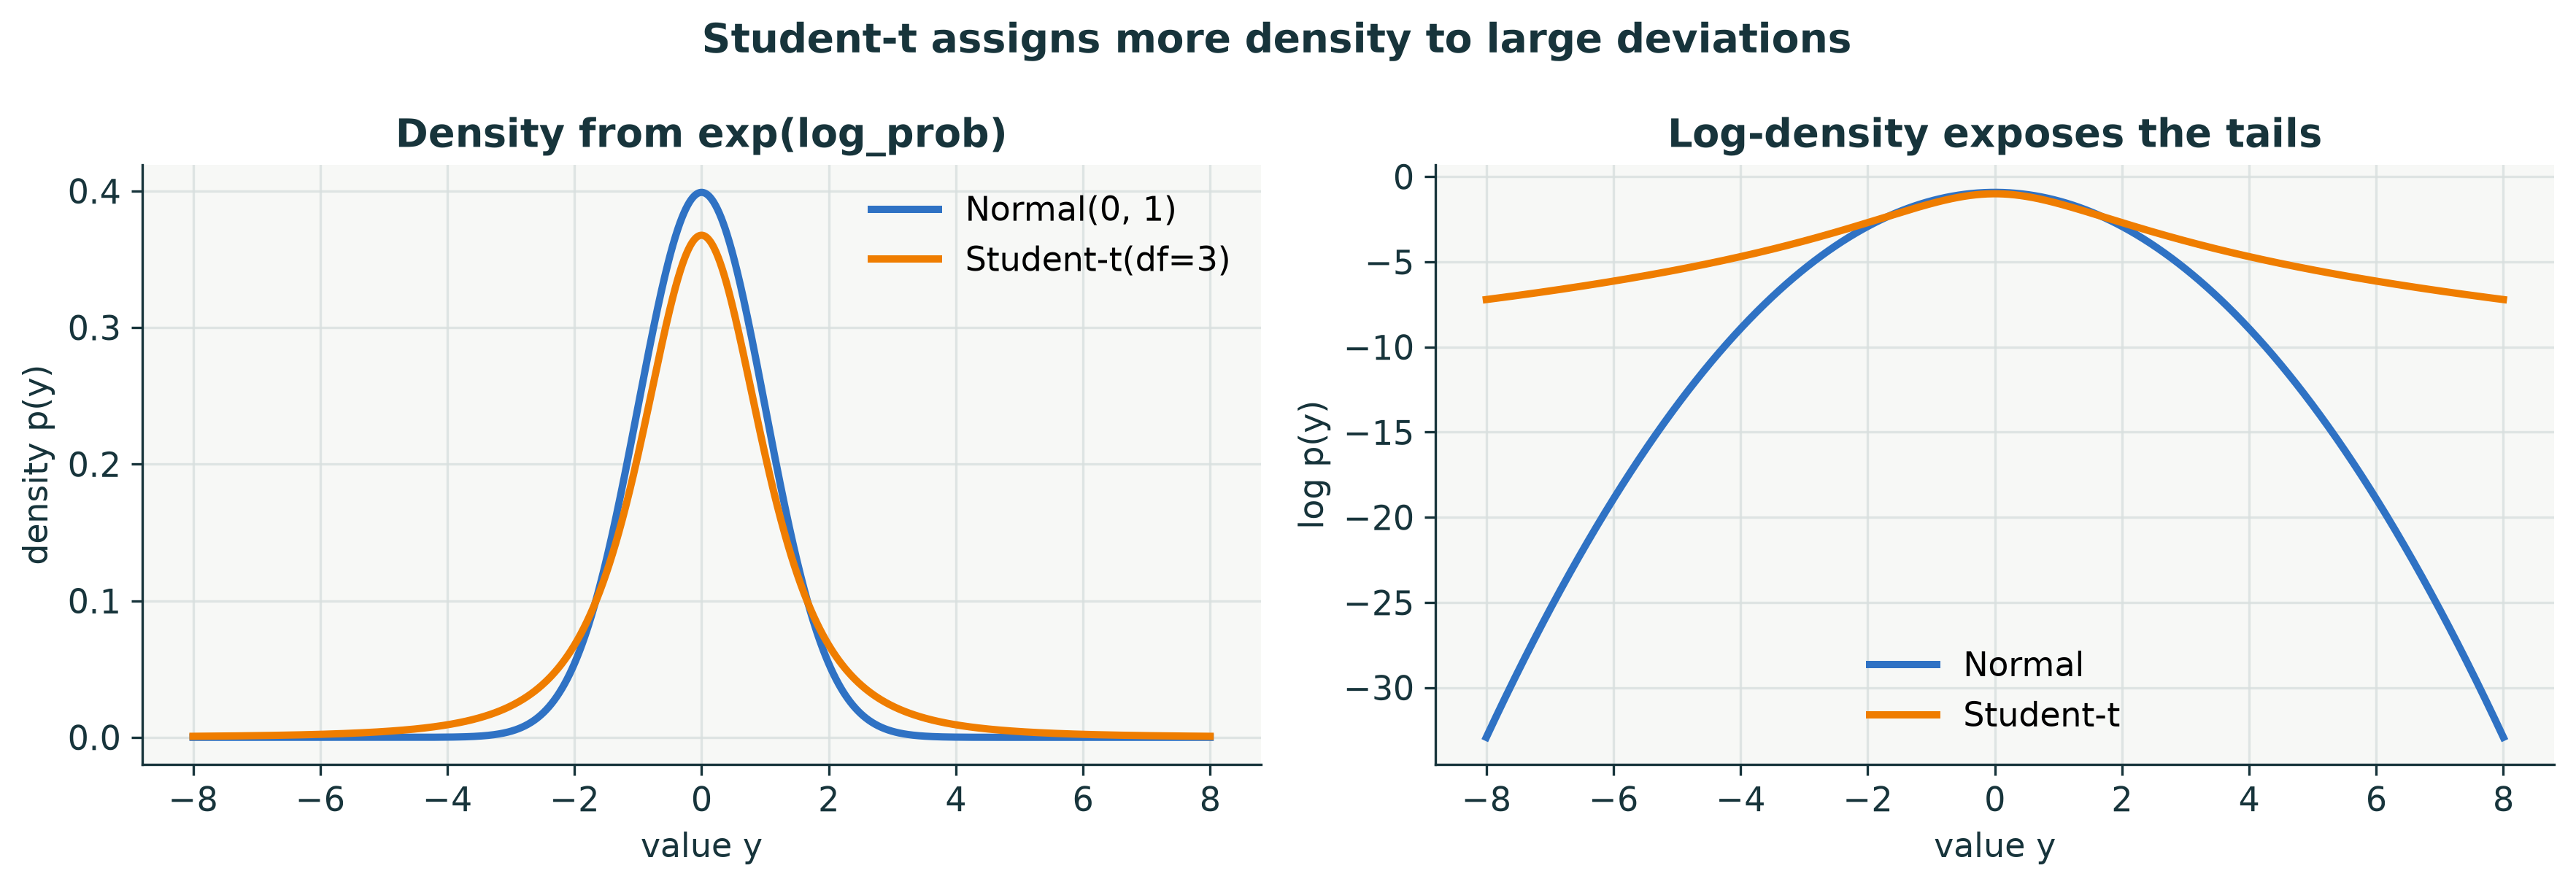

In [2]:
# Plot the two probability densities
fig, axes = plt.subplots(1, 2, figsize=(12, 4.1))

axes[0].plot(npv(x), npv(normal_log_pdf.exp()), color=BLUE, label="Normal(0, 1)")
axes[0].plot(npv(x), npv(student_log_pdf.exp()), color=ORANGE, label="Student-t(df=3)")
axes[0].set(title="Density from exp(log_prob)", xlabel="value y", ylabel="density p(y)")
axes[0].legend()
tidy(axes[0])

# Plot the same models in log-density space
axes[1].plot(npv(x), npv(normal_log_pdf), color=BLUE, label="Normal")
axes[1].plot(npv(x), npv(student_log_pdf), color=ORANGE, label="Student-t")
axes[1].set(title="Log-density exposes the tails", xlabel="value y", ylabel="log p(y)")
axes[1].legend()
tidy(axes[1])

# Finish and display the density comparison
fig.suptitle("Student-t assigns more density to large deviations", fontweight="bold", color=INK)
fig.tight_layout()
plt.show()


In [2]:
# Quantify the heavier Student-t tails
for value in [0.0, 2.0, 6.0]:
    v = torch.tensor(value)
    ratio = (student.log_prob(v) - normal.log_prob(v)).exp()
    print(f"y={value:>3.0f}: Student-t density / Normal density = {ratio.item():.3g}")


y=  0: Student-t density / Normal density = 0.921
y=  2: Student-t density / Normal density = 1.25
y=  6: Student-t density / Normal density = 3.58e+05


**Read the right panel.** A Normal log-density falls quadratically in the tails. A Student-$t$ log-density falls more slowly, so an extreme residual is less surprising under the Student-$t$ model.

### Discrete distributions use the same interface


In [ ]:
# Define three discrete distributions and their supports
outcomes = {
    "Bernoulli(0.75)": (
        torch.arange(2, dtype=torch.get_default_dtype()),
        D.Bernoulli(probs=torch.tensor(0.75)),
    ),
    "Categorical([.1, .3, .6])": (
        torch.arange(3),
        D.Categorical(probs=torch.tensor([0.1, 0.3, 0.6])),
    ),
    "Poisson(rate=3)": (
        torch.arange(10, dtype=torch.get_default_dtype()),
        D.Poisson(rate=torch.tensor(3.0)),
    ),
}


Bernoulli(0.75)              log_prob -> [-1.386, -0.288]
Categorical([.1, .3, .6])    log_prob -> [-2.303, -1.204, -0.511]
Poisson(rate=3)              log_prob -> [-3.0, -1.901, -1.496, -1.496, -1.784, -2.294, -2.988, -3.835, -4.816, -5.914]


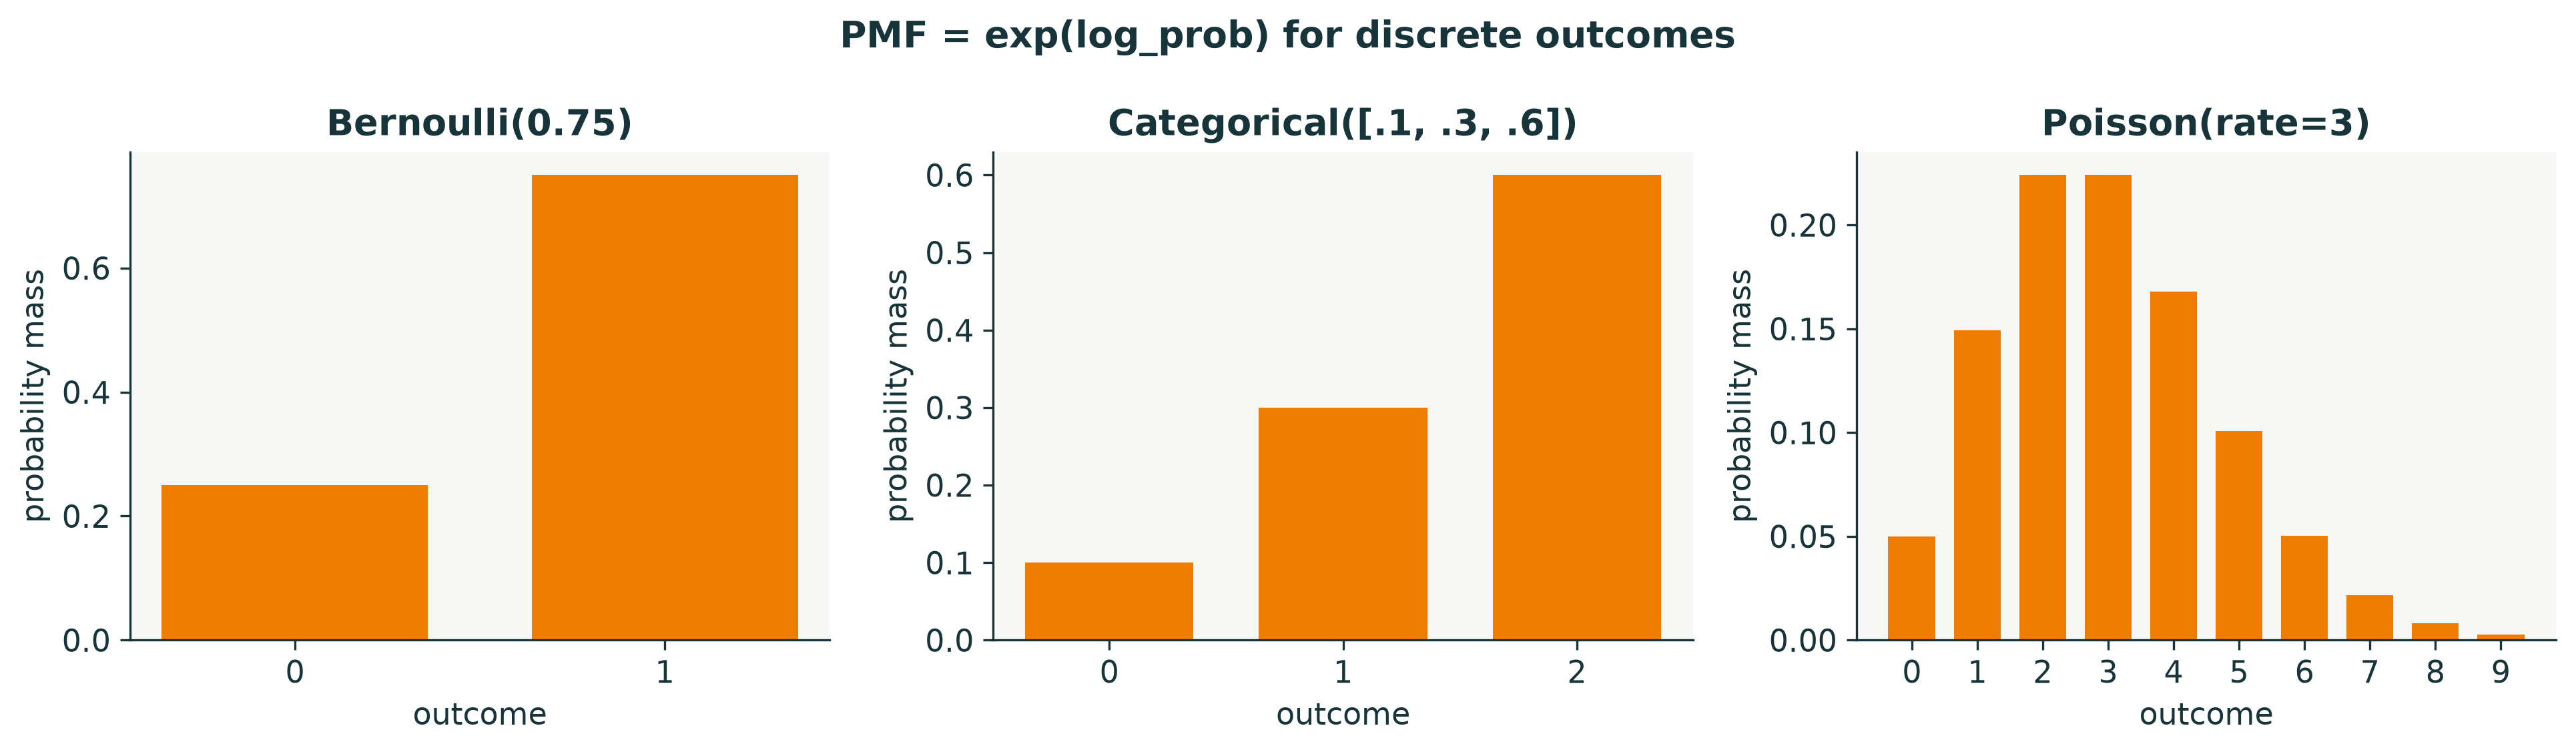

In [3]:
# Evaluate and plot each probability mass function
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (name, (support, distribution)) in zip(axes, outcomes.items()):
    log_mass = distribution.log_prob(support)
    mass = log_mass.exp()
    ax.bar(npv(support), npv(mass), color=ORANGE, width=0.72)
    ax.set(title=name, xlabel="outcome", ylabel="probability mass")
    ax.set_xticks(npv(support))
    tidy(ax, grid=False)
    print(f"{name:28s} log_prob -> {log_mass.round(decimals=3).tolist()}")

# Finish and display the discrete comparison
fig.suptitle("PMF = exp(log_prob) for discrete outcomes", fontweight="bold", color=INK)
fig.tight_layout()
plt.show()


## 2 · Sampling: the model is a data-generating rule

`distribution.sample((n,))` asks the model to generate $n$ observations. A heavy-tailed model produces extreme samples more often.


In [ ]:
# Draw samples from Normal and Student-t models
torch.manual_seed(4)
n_samples = 20_000
normal_samples = normal.sample((n_samples,))
student_samples = student.sample((n_samples,))


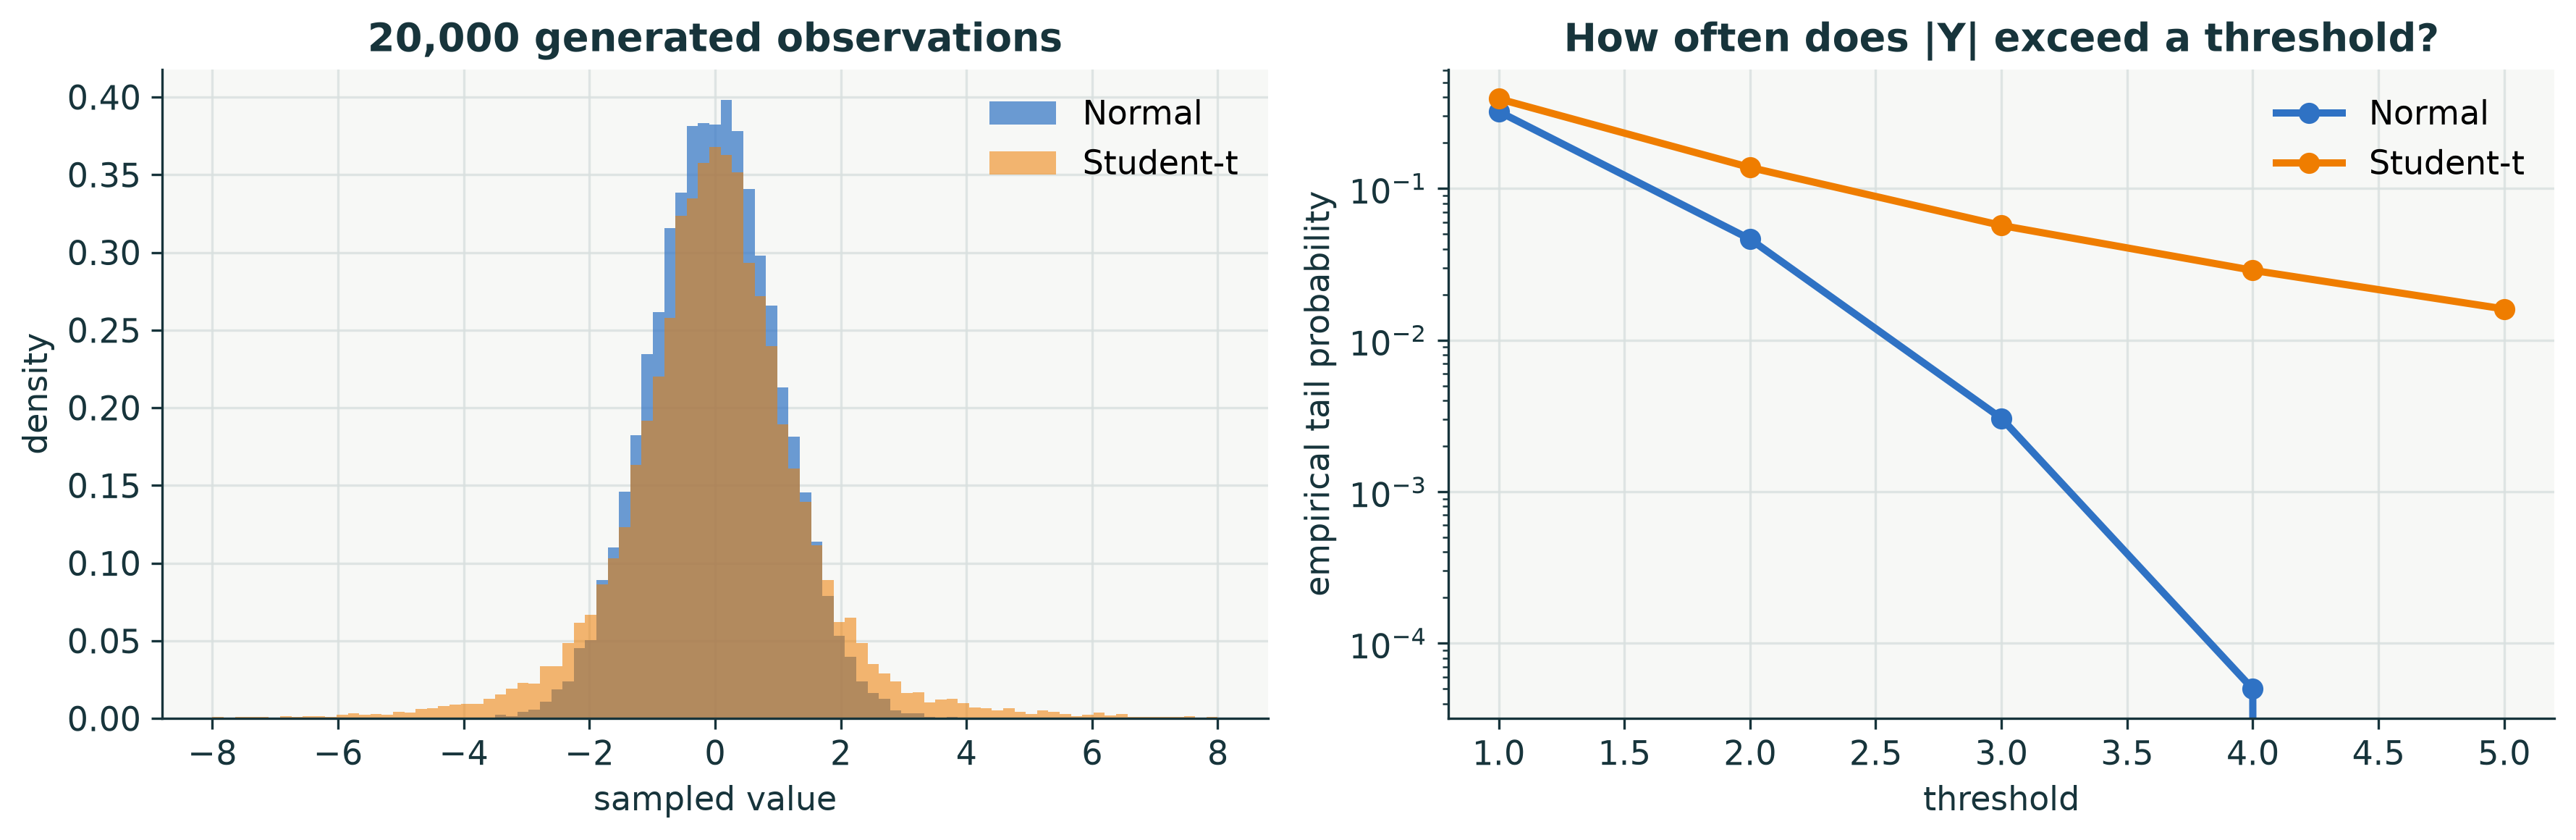

In [4]:
# Compare the sampled histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins = torch.linspace(-8, 8, 90)
axes[0].hist(npv(normal_samples), bins=npv(bins), density=True, alpha=0.7, color=BLUE, label="Normal")
axes[0].hist(npv(student_samples), bins=npv(bins), density=True, alpha=0.55, color=ORANGE, label="Student-t")
axes[0].set(title="20,000 generated observations", xlabel="sampled value", ylabel="density")
axes[0].legend()
tidy(axes[0])

# Estimate tail probabilities from the samples
thresholds = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])
normal_tail = torch.stack([(normal_samples.abs() > t).double().mean() for t in thresholds])
student_tail = torch.stack([(student_samples.abs() > t).double().mean() for t in thresholds])
axes[1].semilogy(npv(thresholds), npv(normal_tail), "o-", color=BLUE, label="Normal")
axes[1].semilogy(npv(thresholds), npv(student_tail), "o-", color=ORANGE, label="Student-t")
axes[1].set(title="How often does |Y| exceed a threshold?", xlabel="threshold", ylabel="empirical tail probability")
axes[1].legend()
tidy(axes[1])

# Display the sampling comparison
fig.tight_layout()
plt.show()


## 3 · The two “I”s in i.i.d.

Suppose one coin model is reused for every flip:

- **identically distributed:** every flip uses the same $\theta$;
- **independent given $\theta$:** after $\theta$ is fixed, one random draw does not alter another.

In the next cell, every pass through the `for` loop is a fresh draw (**independent**), while every pass reuses the same distribution object and the same $\theta$ (**identically distributed**).

Therefore the joint log-probability is a sum:

$$\log p(y_1,\ldots,y_n\mid\theta)=\sum_i\log p(y_i\mid\theta).$$


In [ ]:
# Create one Bernoulli model with a shared parameter
torch.manual_seed(10)
theta = torch.tensor(0.65)
one_coin = D.Bernoulli(probs=theta)  # same distribution reused each time


In [ ]:
# Generate fresh independent flips in a simple loop
flips = []
per_flip_log_prob = []
for i in range(12):
    y_i = one_coin.sample()          # one fresh random draw
    log_p_i = one_coin.log_prob(y_i) # score that one observed outcome
    flips.append(y_i)
    per_flip_log_prob.append(log_p_i)
    outcome = "H" if y_i.item() == 1 else "T"
    print(f"flip {i + 1:2d}: theta={theta.item():.2f}, outcome={outcome}, log_prob={log_p_i.item():.3f}")


In [ ]:
# Collect the per-flip results
flips = torch.stack(flips)
per_flip_log_prob = torch.stack(per_flip_log_prob)


In [ ]:
# Add independent log-probability terms
joint_log_prob = torch.tensor(0.0)
for log_p_i in per_flip_log_prob:
    joint_log_prob = joint_log_prob + log_p_i


In [5]:
# Inspect the IID sample and its joint log probability
print("\nobserved flips:              ", flips.int().tolist())
print("same theta used for every flip:", theta.item())
print("joint log_prob = sum of terms:", joint_log_prob.item())


flip  1: theta=0.65, outcome=T, log_prob=-1.050
flip  2: theta=0.65, outcome=H, log_prob=-0.431
flip  3: theta=0.65, outcome=T, log_prob=-1.050
flip  4: theta=0.65, outcome=H, log_prob=-0.431
flip  5: theta=0.65, outcome=T, log_prob=-1.050
flip  6: theta=0.65, outcome=H, log_prob=-0.431
flip  7: theta=0.65, outcome=H, log_prob=-0.431
flip  8: theta=0.65, outcome=H, log_prob=-0.431
flip  9: theta=0.65, outcome=H, log_prob=-0.431
flip 10: theta=0.65, outcome=T, log_prob=-1.050
flip 11: theta=0.65, outcome=H, log_prob=-0.431
flip 12: theta=0.65, outcome=H, log_prob=-0.431

observed flips:               [0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1]
same theta used for every flip: 0.65
joint log_prob = sum of terms: -7.645551826734344


**What each assumption contributes**

| Data-generating story | Independent? | Identical? |
|---|:---:|:---:|
| Repeated flips of one fixed coin | yes | yes |
| Two separate sensors with different noise scales | yes | no |
| Daily weather depending on yesterday | no | possibly |

The product comes from **independence**. Reusing one common factor form and parameter comes from **identical distribution**.


## 4 · Coin-toss MLE: first inspect every observation

We observed `H,H,T,T,T,H,H,T,T,T`: four heads and six tails. For a candidate $\theta$,

$$\log L(\theta)=\sum_i \log p(y_i\mid\theta).$$

**Checkpoint.** Before running: should $\theta=0.4$ or $\theta=0.7$ receive the larger likelihood?


In [ ]:
# Choose observed flips and two candidate coin biases
coin_data = torch.tensor([1, 1, 0, 0, 0, 1, 1, 0, 0, 0.0])
candidates = torch.tensor([0.4, 0.7])


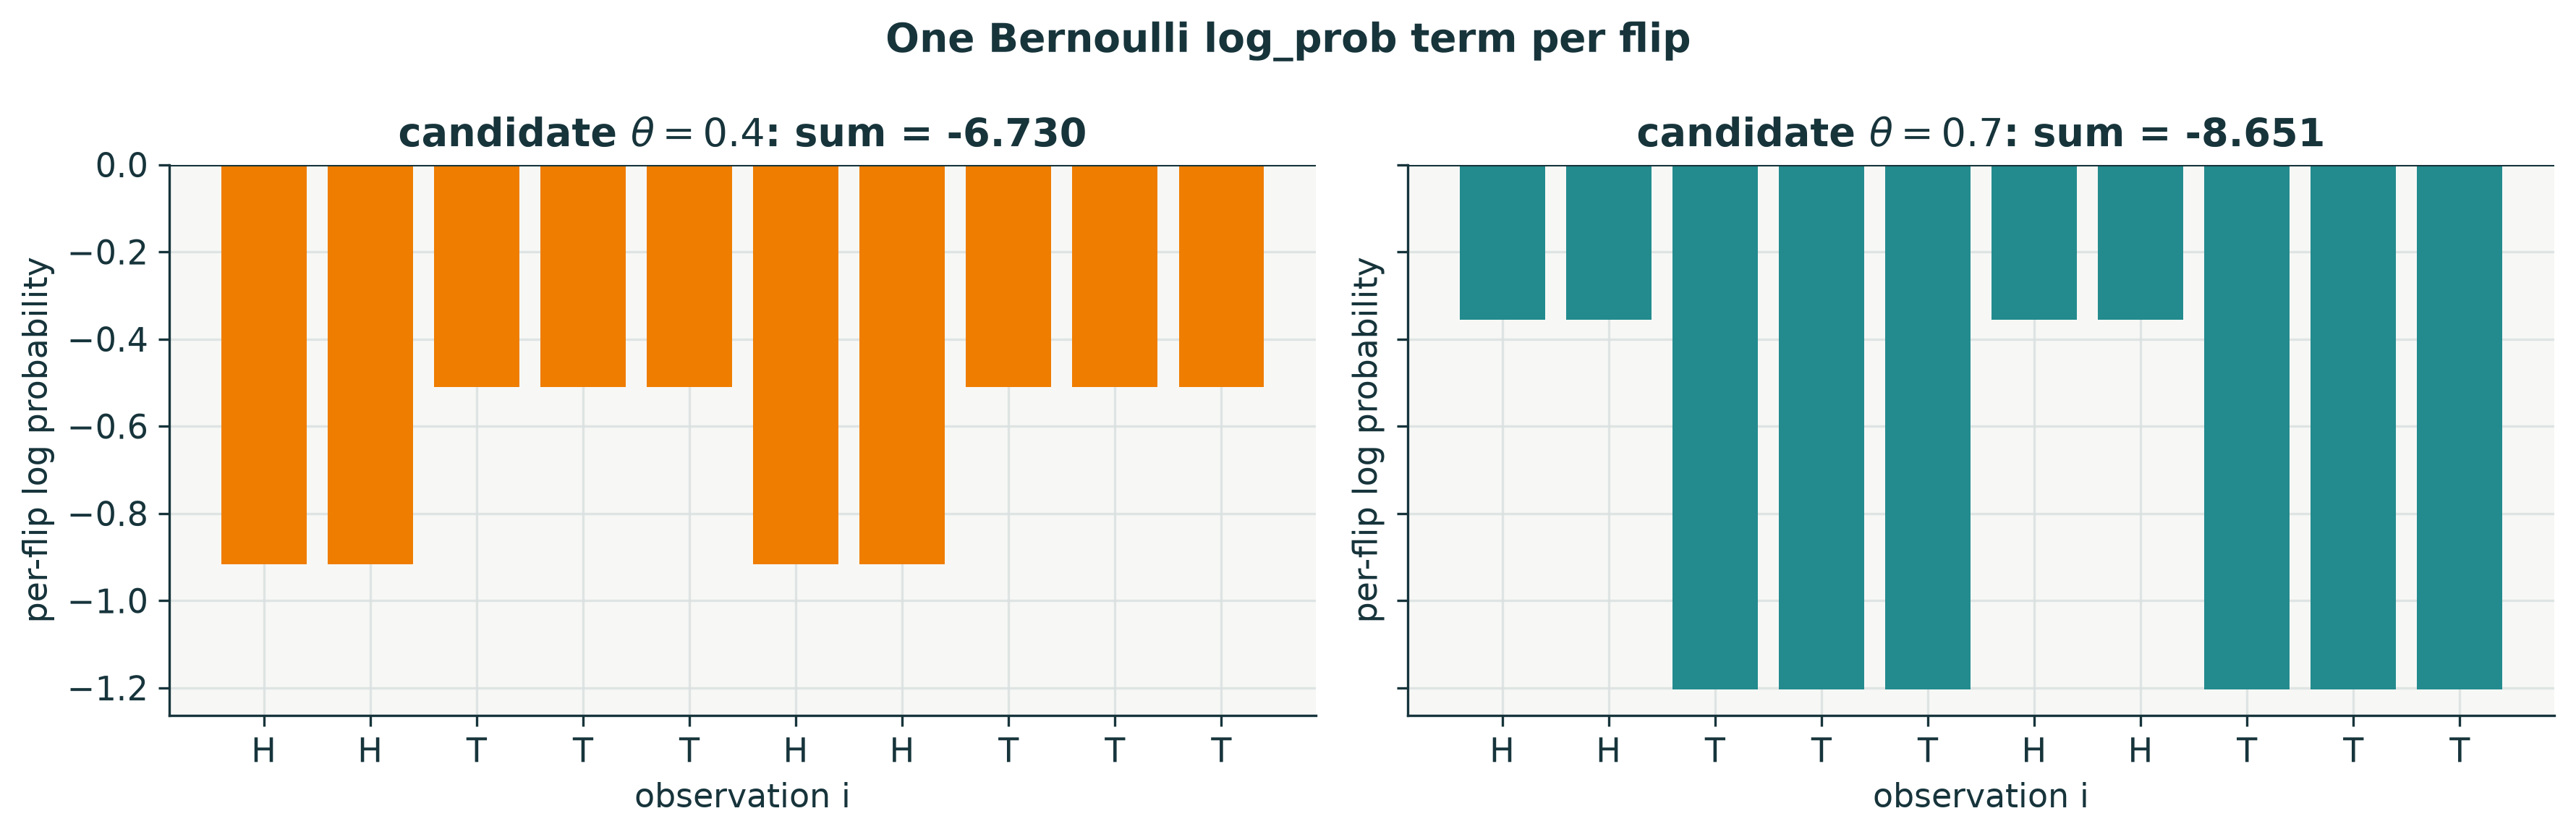

In [6]:
# Compute one log-probability term per flip
fig, axes = plt.subplots(1, 2, figsize=(12, 3.9), sharey=True)
for ax, candidate, color in zip(axes, candidates, [ORANGE, TEAL]):
    candidate_coin = D.Bernoulli(probs=candidate)
    terms = []
    for y_i in coin_data:
        terms.append(candidate_coin.log_prob(y_i))
    terms = torch.stack(terms)
    ax.bar(torch.arange(len(coin_data)), npv(terms), color=color)
    ax.axhline(0, color=INK, linewidth=1)
    ax.set(
        title=rf"candidate $\theta={candidate.item():.1f}$: sum = {terms.sum().item():.3f}",
        xlabel="observation i",
        ylabel="per-flip log probability",
    )
    ax.set_xticks(torch.arange(len(coin_data)), ["H" if y else "T" for y in coin_data])
    tidy(ax)

# Display the per-example likelihood comparison
fig.suptitle("One Bernoulli log_prob term per flip", fontweight="bold", color=INK)
fig.tight_layout()
plt.show()


In [ ]:
# Define the coin log-likelihood as an explicit sum
def coin_log_likelihood(theta_candidate):
    coin = D.Bernoulli(probs=theta_candidate)
    total = torch.tensor(0.0)
    for y_i in coin_data:
        total = total + coin.log_prob(y_i)
    return total


In [ ]:
# Evaluate likelihood over candidate parameter values
theta_grid = torch.linspace(0.01, 0.99, 500)
log_likelihood = torch.stack([coin_log_likelihood(t) for t in theta_grid])
likelihood = log_likelihood.exp()
theta_mle_grid = theta_grid[log_likelihood.argmax()]
theta_mle_closed = coin_data.mean()


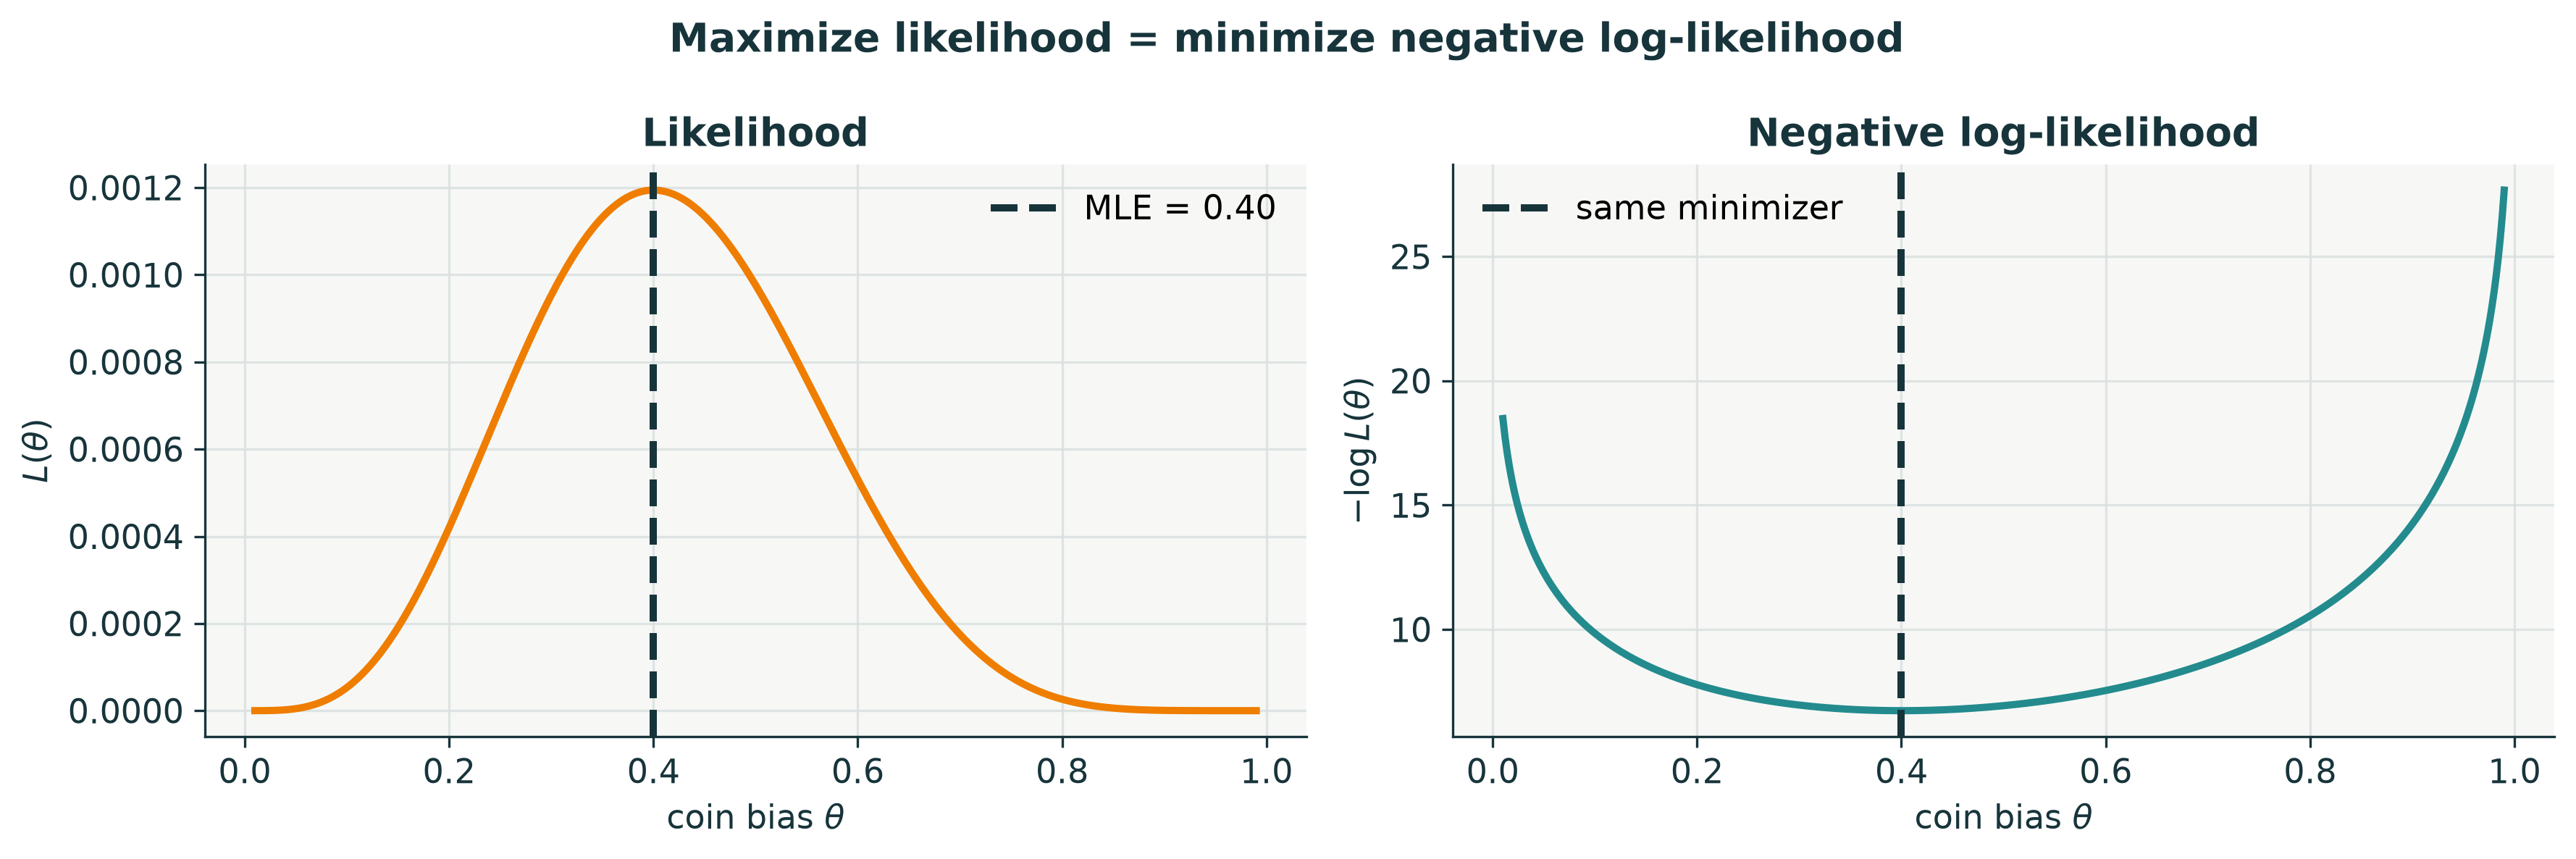

In [7]:
# Plot the likelihood and mark its maximum
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(npv(theta_grid), npv(likelihood), color=ORANGE)
axes[0].axvline(theta_mle_closed, color=INK, linestyle="--", label=rf"MLE = {theta_mle_closed:.2f}")
axes[0].set(title="Likelihood", xlabel=r"coin bias $\theta$", ylabel=r"$L(\theta)$")
axes[0].legend()
tidy(axes[0])

# Plot NLL and mark the same optimum
axes[1].plot(npv(theta_grid), npv(-log_likelihood), color=TEAL)
axes[1].axvline(theta_mle_closed, color=INK, linestyle="--", label="same minimizer")
axes[1].set(title="Negative log-likelihood", xlabel=r"coin bias $\theta$", ylabel=r"$-\log L(\theta)$")
axes[1].legend()
tidy(axes[1])

# Display likelihood and NLL together
fig.suptitle("Maximize likelihood = minimize negative log-likelihood", fontweight="bold", color=INK)
fig.tight_layout()
plt.show()


In [7]:
# Compare grid and closed-form MLEs
print(f"grid MLE        = {theta_mle_grid.item():.4f}")
print(f"closed-form MLE = heads / flips = {theta_mle_closed.item():.4f}")


grid MLE        = 0.4008
closed-form MLE = heads / flips = 0.4000


In [ ]:
# Initialize an unconstrained coin logit
coin_logit = torch.tensor(0.0, requires_grad=True)
optimizer = torch.optim.Adam([coin_logit], lr=0.12)
coin_history = []


In [ ]:
# Optimize Bernoulli NLL by gradient descent
for step in range(180):
    optimizer.zero_grad()
    model = D.Bernoulli(logits=coin_logit)
    negative_log_probs = []
    for y_i in coin_data:
        negative_log_probs.append(-model.log_prob(y_i))
    loss = torch.stack(negative_log_probs).mean()
    loss.backward()
    optimizer.step()
    coin_history.append((loss.item(), coin_logit.sigmoid().item()))


In [8]:
# Report the gradient-descent MLE
print(f"gradient-descent MLE = {coin_logit.sigmoid().item():.4f}")
print("The unconstrained logit is optimized; sigmoid keeps theta in (0, 1).")


gradient-descent MLE = 0.4000
The unconstrained logit is optimized; sigmoid keeps theta in (0, 1).


## 5 · Linear regression is a Gaussian data-generating process

We will generate data from

$$Y_i\mid x_i,\boldsymbol\theta \sim
\mathcal N\!\left(b+w x_i,\sigma^2\right),\qquad
\boldsymbol\theta=(b,w).$$

Equivalently, $y_i=b+w x_i+\varepsilon_i$ with $\varepsilon_i\sim\mathcal N(0,\sigma^2)$.
Here $\sigma$ is known, so we estimate only the intercept and slope.


In [ ]:
# Set the linear-regression data-generating parameters
torch.manual_seed(22)
n_reg = 28
x_reg = torch.linspace(-1.3, 1.3, n_reg)
theta_true = torch.tensor([2.0, 3.0])  # [intercept b, slope w]
sigma = torch.tensor(0.42)
mean_true = theta_true[0] + theta_true[1] * x_reg


In [9]:
# Sample one output for each input in a loop
y_reg = []
for i, x_i in enumerate(x_reg):
    mu_i = theta_true[0] + theta_true[1] * x_i
    model_i = D.Normal(loc=mu_i, scale=sigma)
    y_i = model_i.sample()
    y_reg.append(y_i)
    if i < 5:
        print(f"i={i:2d}: x_i={x_i.item(): .2f}, mean={mu_i.item(): .2f}, sampled y_i={y_i.item(): .2f}")
y_reg = torch.stack(y_reg)


i= 0: x_i=-1.30, mean=-1.90, sampled y_i=-1.47
i= 1: x_i=-1.20, mean=-1.61, sampled y_i=-1.82
i= 2: x_i=-1.11, mean=-1.32, sampled y_i=-1.36
i= 3: x_i=-1.01, mean=-1.03, sampled y_i=-0.46
i= 4: x_i=-0.91, mean=-0.74, sampled y_i=-2.04


In [ ]:
# Prepare the true mean on a dense input grid
x_dense = torch.linspace(-1.45, 1.45, 400)
mean_dense = theta_true[0] + theta_true[1] * x_dense


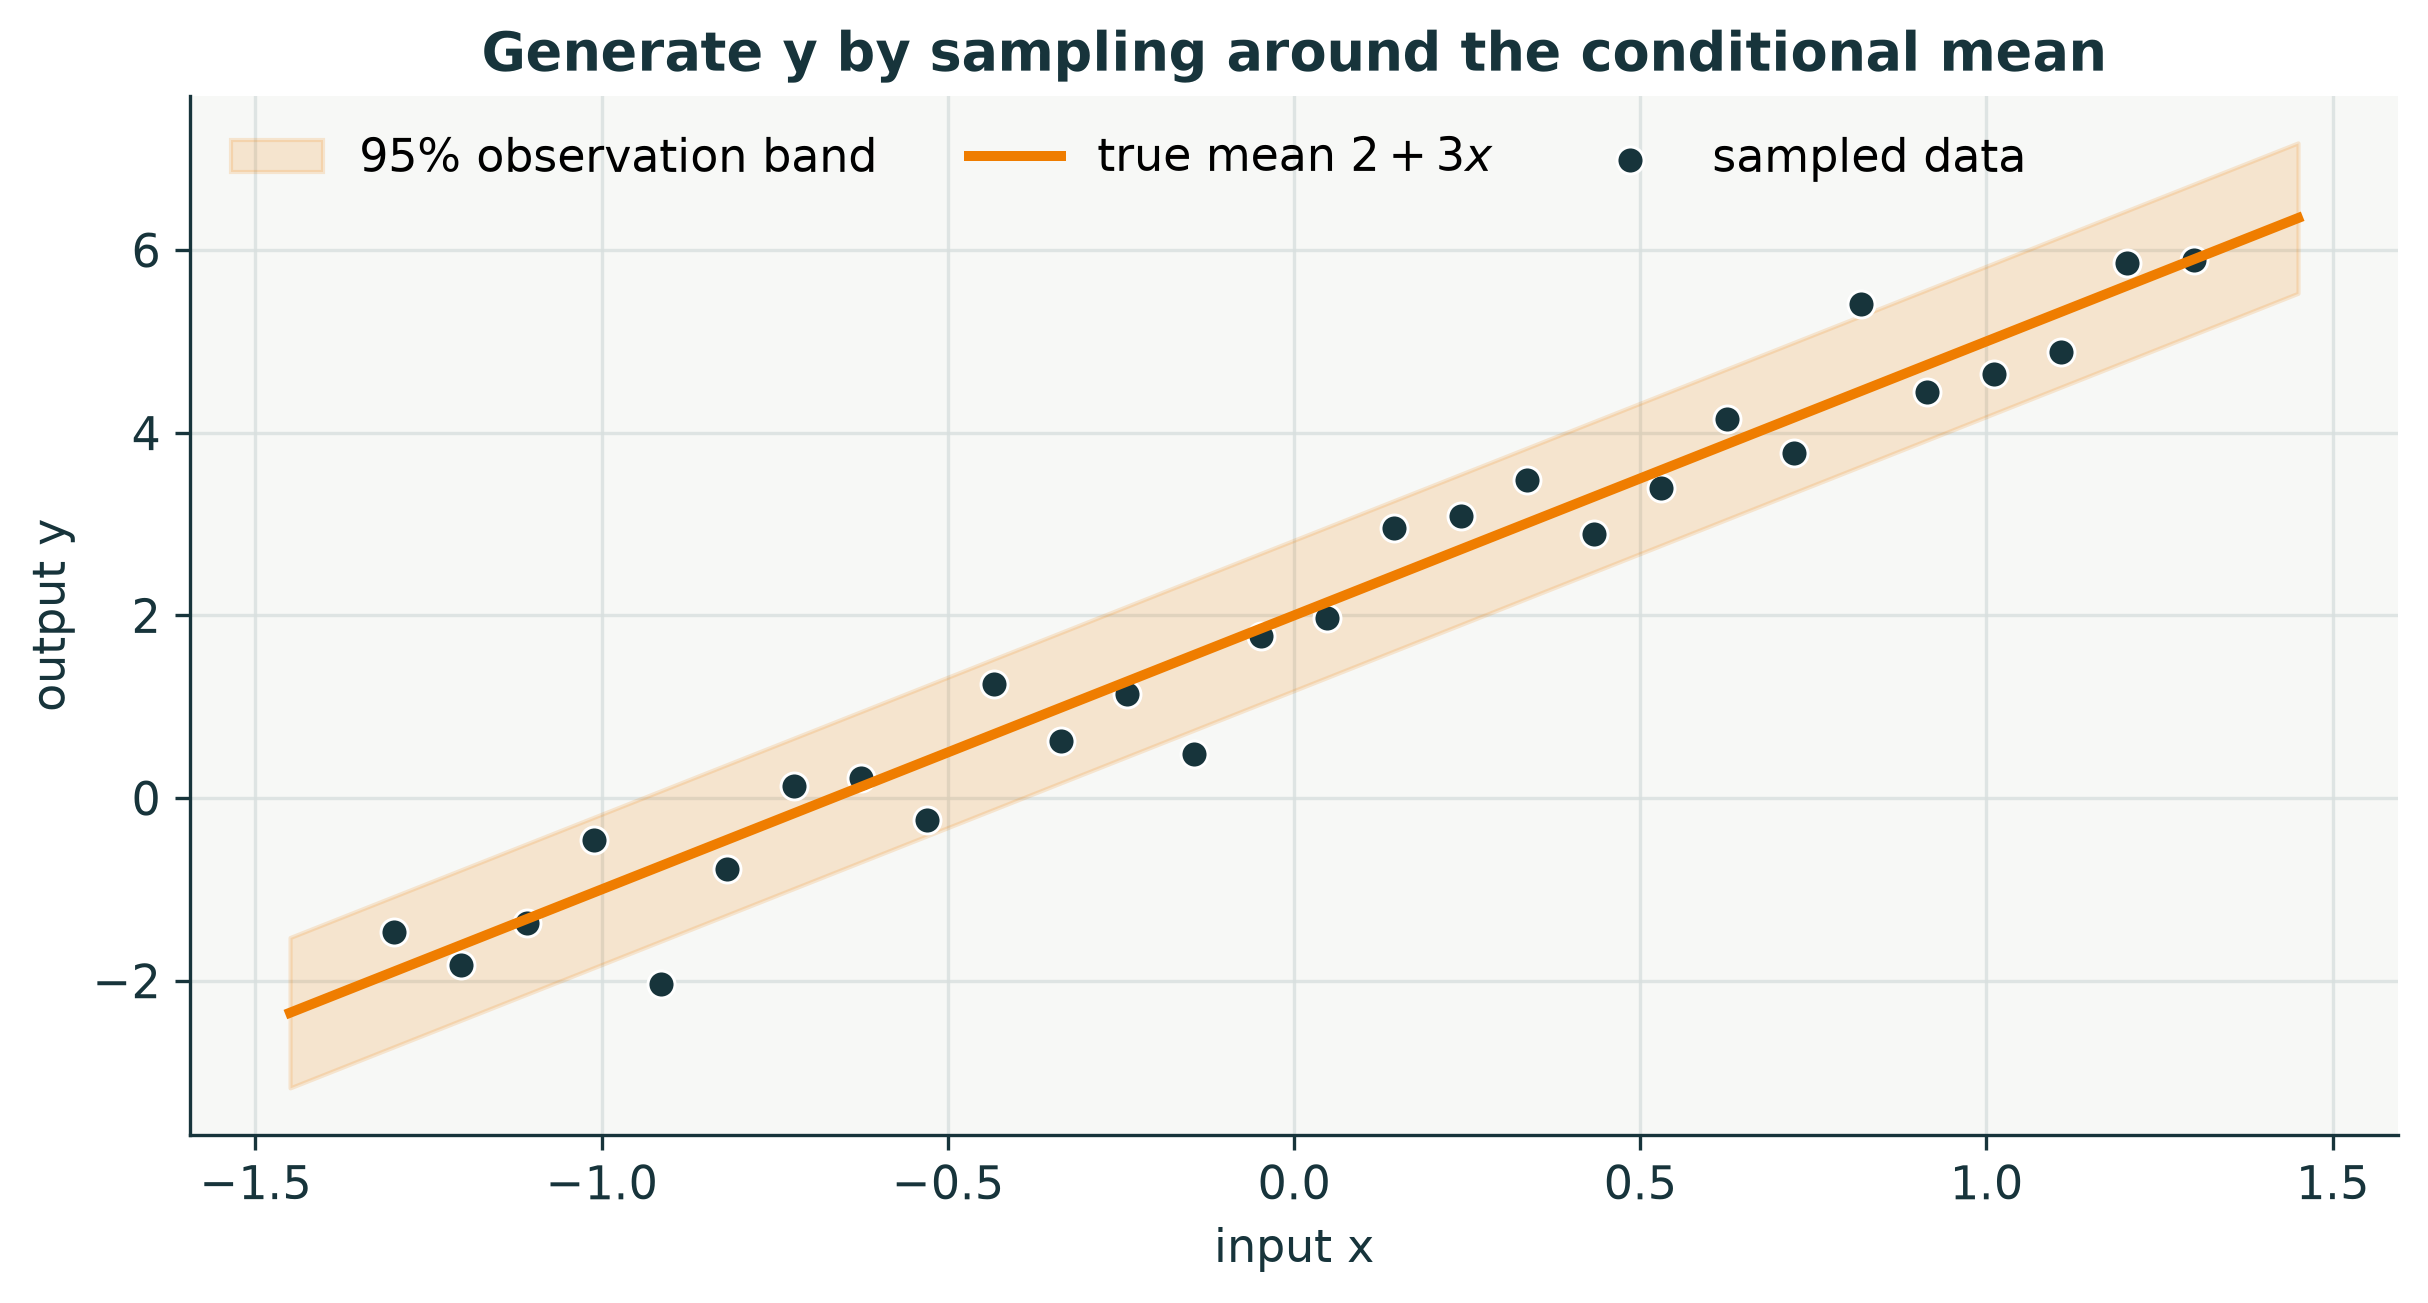

In [9]:
# Plot the sampled data and observation band
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.fill_between(
    npv(x_dense), npv(mean_dense - 1.96 * sigma), npv(mean_dense + 1.96 * sigma),
    color=ORANGE, alpha=0.16, label="95% observation band"
)
ax.plot(npv(x_dense), npv(mean_dense), color=ORANGE, label=r"true mean $2+3x$")
ax.scatter(npv(x_reg), npv(y_reg), s=42, color=INK, edgecolor="white", linewidth=0.7, label="sampled data")
ax.set(title="Generate y by sampling around the conditional mean", xlabel="input x", ylabel="output y")
ax.legend(ncols=3)
tidy(ax)
plt.show()


In [9]:
# State the shared-model interpretation
print("\nOne independent Normal draw for each x_i; the same b, w, and sigma define every draw.")



One independent Normal draw for each x_i; the same b, w, and sigma define every draw.


### Per-sample log-density first; sum second

For a candidate $\boldsymbol\theta$, PyTorch returns one log-density per observation. Independence lets us add them.


In [ ]:
# Score one candidate regression line example by example
theta_candidate = torch.tensor([1.45, 2.25])
candidate_mean = theta_candidate[0] + theta_candidate[1] * x_reg
per_sample_log_prob = []
for x_i, y_i in zip(x_reg, y_reg):
    mu_i = theta_candidate[0] + theta_candidate[1] * x_i
    model_i = D.Normal(loc=mu_i, scale=sigma)
    per_sample_log_prob.append(model_i.log_prob(y_i))
per_sample_log_prob = torch.stack(per_sample_log_prob)
total_log_likelihood = per_sample_log_prob.sum()


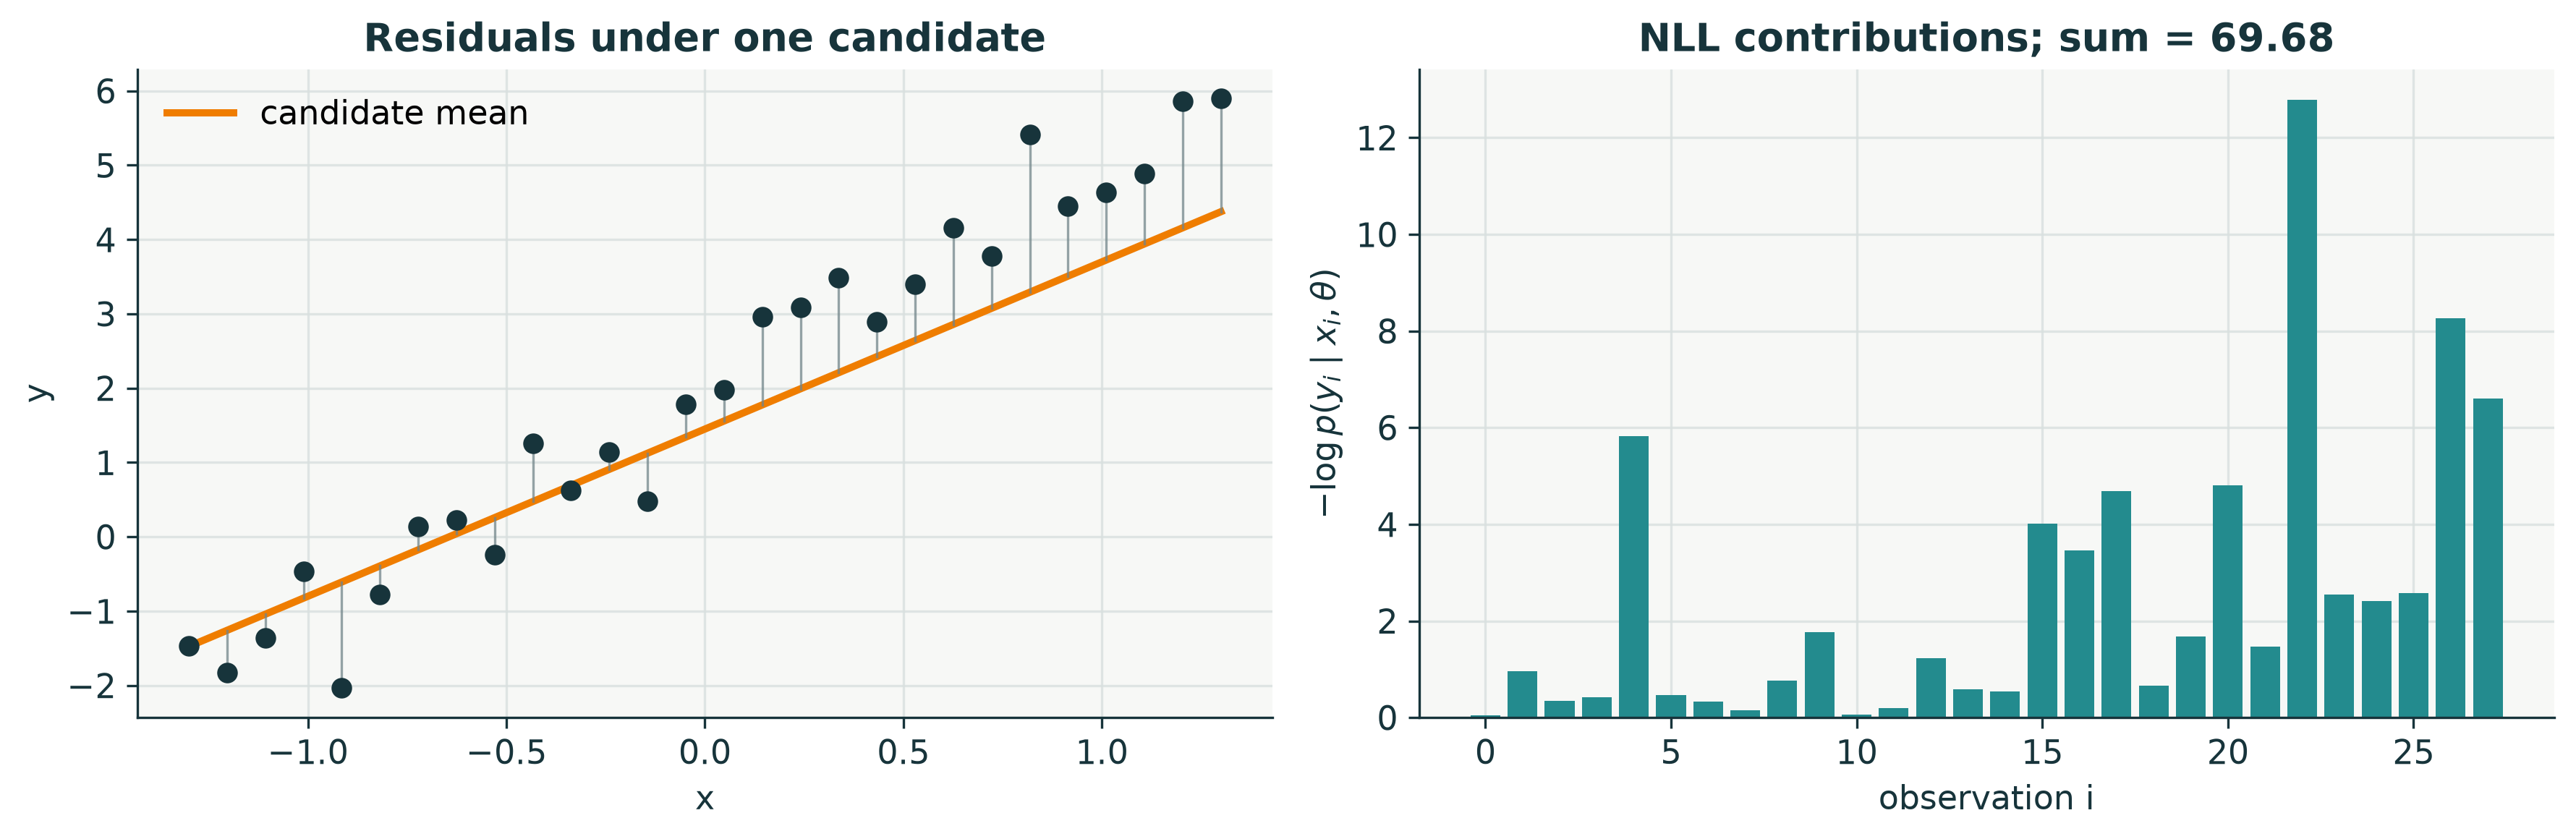

In [10]:
# Plot residuals for the candidate line
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(npv(x_reg), npv(y_reg), color=INK, s=34, zorder=3)
axes[0].plot(npv(x_reg), npv(candidate_mean), color=ORANGE, label="candidate mean")
for xi, yi, mui in zip(x_reg, y_reg, candidate_mean):
    axes[0].plot([xi, xi], [mui, yi], color=MUTED, linewidth=0.8, alpha=0.75)
axes[0].set(title="Residuals under one candidate", xlabel="x", ylabel="y")
axes[0].legend()
tidy(axes[0])

# Plot every observation's NLL contribution
axes[1].bar(torch.arange(n_reg), npv(-per_sample_log_prob), color=TEAL)
axes[1].set(title=f"NLL contributions; sum = {-total_log_likelihood.item():.2f}", xlabel="observation i", ylabel=r"$-\log p(y_i\mid x_i,\theta)$")
tidy(axes[1])

# Display residuals beside their loss terms
fig.tight_layout()
plt.show()


### Gaussian NLL and MSE have the same minimizer

With fixed $\sigma$,

$$\frac1n\sum_i-\log p(y_i\mid x_i,\boldsymbol\theta)
=\frac{1}{2\sigma^2}\operatorname{MSE}(\boldsymbol\theta)+C.$$

The scale and vertical offset differ; the best $(b,w)$ does not. The next cell evaluates many candidate $(b,w)$ values at once only to draw the contour plots; it is the same per-observation calculation shown in the loop above.


In [ ]:
# Evaluate Gaussian NLL and MSE over parameter space
b_values = torch.linspace(0.2, 3.4, 121)
w_values = torch.linspace(1.0, 4.8, 121)
B, W = torch.meshgrid(b_values, w_values, indexing="xy")
grid_mean = B[..., None] + W[..., None] * x_reg
mean_nll_surface = -D.Normal(grid_mean, sigma).log_prob(y_reg).mean(dim=-1)
mse_surface = ((grid_mean - y_reg) ** 2).mean(dim=-1)


In [ ]:
# Compute the closed-form least-squares estimate
design = torch.column_stack((torch.ones_like(x_reg), x_reg))
theta_ols = torch.linalg.lstsq(design, y_reg).solution


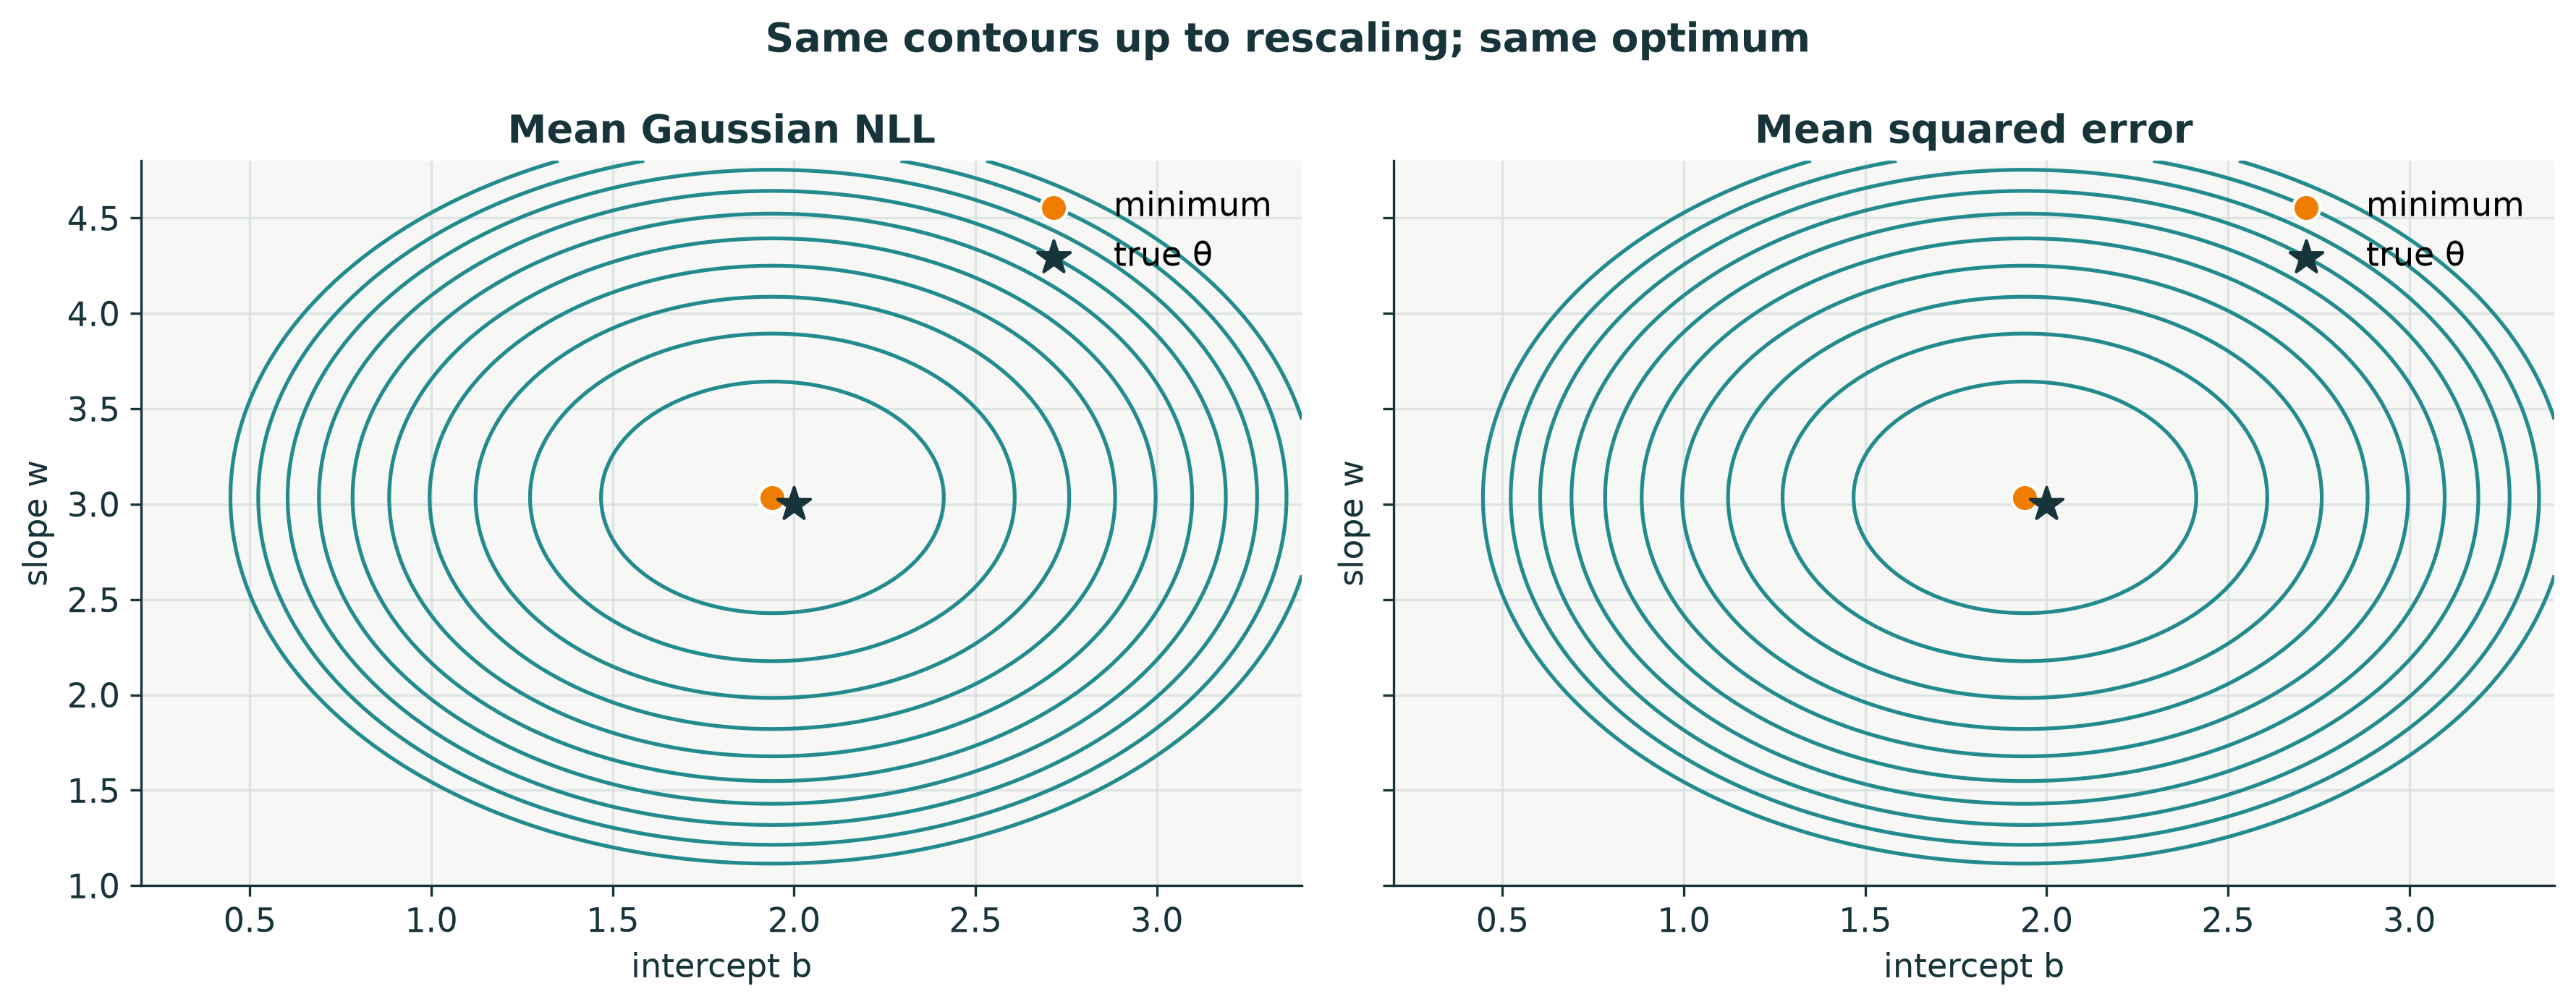

In [11]:
# Plot the two objective surfaces
fig, axes = plt.subplots(1, 2, figsize=(12, 4.7), sharex=True, sharey=True)
surfaces = [mean_nll_surface, mse_surface]
titles = ["Mean Gaussian NLL", "Mean squared error"]
for ax, surface, title in zip(axes, surfaces, titles):
    levels = torch.linspace(surface.min(), torch.quantile(surface.flatten(), 0.72), 11)
    ax.contour(npv(B), npv(W), npv(surface), levels=npv(levels), colors=TEAL, linewidths=1.25)
    ax.scatter(theta_ols[0], theta_ols[1], color=ORANGE, s=80, edgecolor="white", label="minimum", zorder=4)
    ax.scatter(theta_true[0], theta_true[1], marker="*", color=INK, s=130, label="true θ", zorder=4)
    ax.set(title=title, xlabel="intercept b", ylabel="slope w")
    ax.legend()
    tidy(ax)

# Display the matching objective geometry
fig.suptitle("Same contours up to rescaling; same optimum", fontweight="bold", color=INK)
fig.tight_layout()
plt.show()


In [11]:
# Verify the NLL–MSE identity numerically
relation_error = (
    mean_nll_surface
    - mse_surface / (2 * sigma**2)
    - torch.log(sigma * math.sqrt(2 * math.pi))
).abs().max()
print(f"largest numerical error in NLL = MSE/(2 sigma^2) + C: {relation_error.item():.2e}")
print(f"closed-form least-squares estimate [b, w]: {theta_ols.tolist()}")


largest numerical error in NLL = MSE/(2 sigma^2) + C: 5.97e-15
closed-form least-squares estimate [b, w]: [1.9403994737286643, 3.0355771137191456]


In [ ]:
# Define one loop-based optimizer for NLL or MSE
def fit_regression(kind, steps=350):
    theta = torch.tensor([-0.5, 0.0], requires_grad=True)
    optimizer = torch.optim.Adam([theta], lr=0.07)
    history = []
    for _ in range(steps):
        optimizer.zero_grad()
        per_example_losses = []
        for x_i, y_i in zip(x_reg, y_reg):
            prediction_i = theta[0] + theta[1] * x_i
            if kind == "nll":
                loss_i = -D.Normal(prediction_i, sigma).log_prob(y_i)
            elif kind == "mse":
                loss_i = (prediction_i - y_i) ** 2
            else:
                raise ValueError(kind)
            per_example_losses.append(loss_i)
        loss = torch.stack(per_example_losses).mean()
        loss.backward()
        optimizer.step()
        history.append(loss.item())
    return theta.detach(), torch.tensor(history)


In [ ]:
# Fit the regression model with both objectives
theta_nll, nll_history = fit_regression("nll")
theta_mse, mse_history = fit_regression("mse")


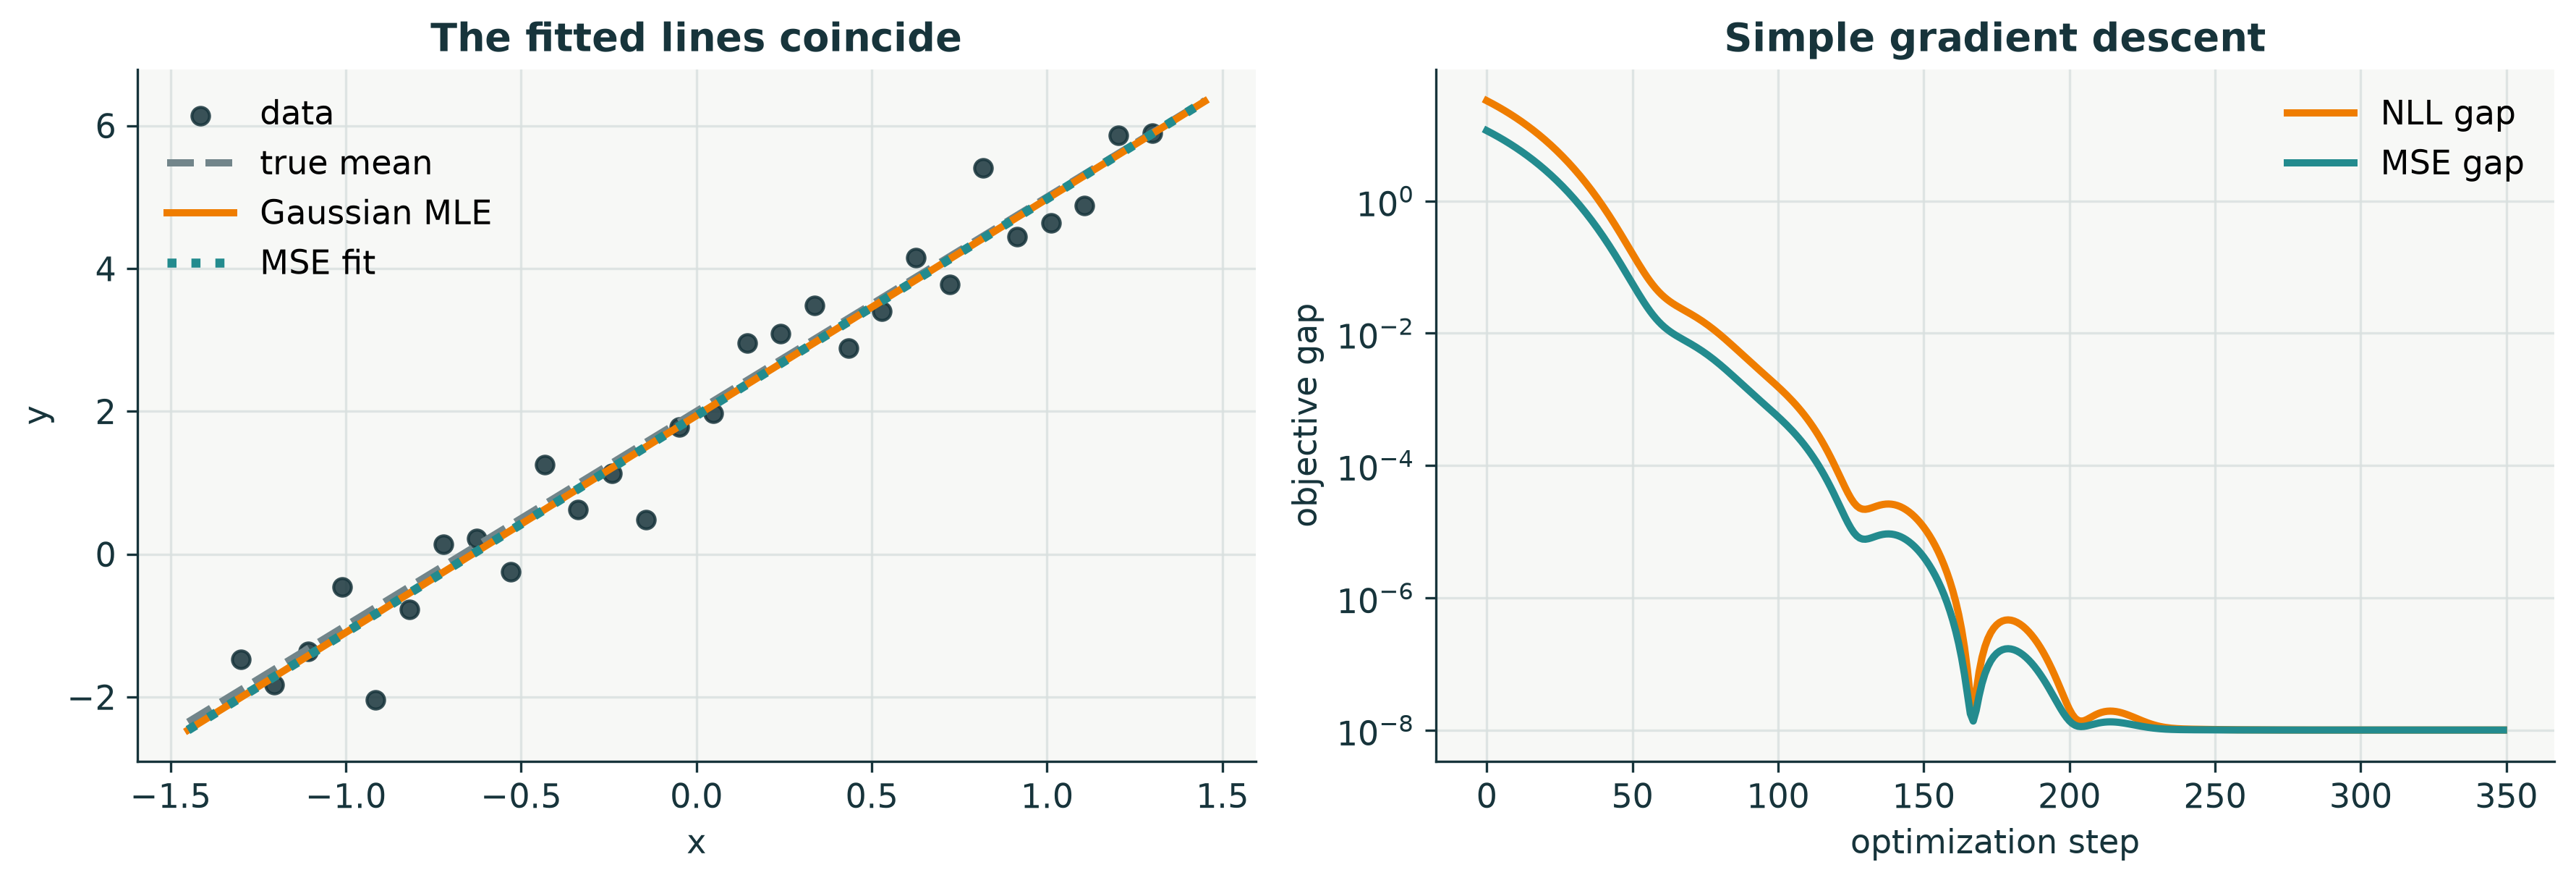

In [12]:
# Compare the fitted regression lines
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].scatter(npv(x_reg), npv(y_reg), s=34, color=INK, alpha=0.85, label="data")
axes[0].plot(npv(x_dense), npv(theta_true[0] + theta_true[1] * x_dense), color=MUTED, linestyle="--", label="true mean")
axes[0].plot(npv(x_dense), npv(theta_nll[0] + theta_nll[1] * x_dense), color=ORANGE, label="Gaussian MLE")
axes[0].plot(npv(x_dense), npv(theta_mse[0] + theta_mse[1] * x_dense), color=TEAL, linestyle=":", linewidth=3, label="MSE fit")
axes[0].set(title="The fitted lines coincide", xlabel="x", ylabel="y")
axes[0].legend()
tidy(axes[0])

# Compare the two optimization histories
axes[1].semilogy(npv(nll_history - nll_history.min() + 1e-8), color=ORANGE, label="NLL gap")
axes[1].semilogy(npv(mse_history - mse_history.min() + 1e-8), color=TEAL, label="MSE gap")
axes[1].set(title="Simple gradient descent", xlabel="optimization step", ylabel="objective gap")
axes[1].legend()
tidy(axes[1])

# Display the fitted lines and convergence
fig.tight_layout()
plt.show()


In [12]:
# Confirm both objectives reached the same parameters
print("NLL estimate [b, w]:", theta_nll.round(decimals=4).tolist())
print("MSE estimate [b, w]:", theta_mse.round(decimals=4).tolist())
print("maximum parameter difference:", (theta_nll - theta_mse).abs().max().item())


NLL estimate [b, w]: [1.9404, 3.0356]
MSE estimate [b, w]: [1.9404, 3.0356]
maximum parameter difference: 7.993605777301127e-15


## 6 · Binary classification uses Bernoulli outcome noise

For two input features $\mathbf x=(x_1,x_2)$,

$$z=\theta_0+\theta_1x_1+\theta_2x_2,\qquad
p=\sigma(z),\qquad Y\mid\mathbf x\sim\operatorname{Bernoulli}(p).$$

There is no additive Gaussian $\varepsilon$. The randomness is the Bernoulli draw itself: even at the same $\mathbf x$, either class may occur unless $p$ is exactly 0 or 1.


In [ ]:
# Generate two-feature inputs for binary classification
torch.manual_seed(31)
n_cls = 220
X_cls = D.Normal(torch.zeros(2), torch.ones(2)).sample((n_cls,))
theta_cls_true = torch.tensor([0.25, 2.2, -1.55])  # intercept, two weights


In [13]:
# Sample one Bernoulli class label at a time
logits_true = []
p_true = []
y_cls = []
for i, x_i in enumerate(X_cls):
    z_i = theta_cls_true[0] + x_i @ theta_cls_true[1:]
    p_i = z_i.sigmoid()
    y_i = D.Bernoulli(probs=p_i).sample()
    logits_true.append(z_i)
    p_true.append(p_i)
    y_cls.append(y_i)
    if i < 5:
        print(f"i={i:2d}: x_i={x_i.tolist()}, p_i={p_i.item():.3f}, sampled y_i={int(y_i.item())}")


i= 0: x_i=[-0.3742734747681159, 0.36149981860651825], p_i=0.243, sampled y_i=0
i= 1: x_i=[1.1415435750955787, 0.304086278900781], p_i=0.908, sampled y_i=0
i= 2: x_i=[0.21000212817127462, 0.9447677766281334], p_i=0.320, sampled y_i=0
i= 3: x_i=[0.9181844686165579, 1.0423662778843081], p_i=0.658, sampled y_i=1
i= 4: x_i=[1.8716675844537638, 0.5622390836857495], p_i=0.971, sampled y_i=1


In [ ]:
# Collect the sampled logits, probabilities, and labels
logits_true = torch.stack(logits_true)
p_true = torch.stack(p_true)
y_cls = torch.stack(y_cls)


In [ ]:
# Create a grid for visualizing class probabilities
grid_limit = X_cls.abs().max().ceil().item() + 0.2
g1 = torch.linspace(-grid_limit, grid_limit, 240)
g2 = torch.linspace(-grid_limit, grid_limit, 240)
G1, G2 = torch.meshgrid(g1, g2, indexing="xy")


In [ ]:
# Define the probability surface produced by parameters
def probability_grid(theta):
    return (theta[0] + theta[1] * G1 + theta[2] * G2).sigmoid()


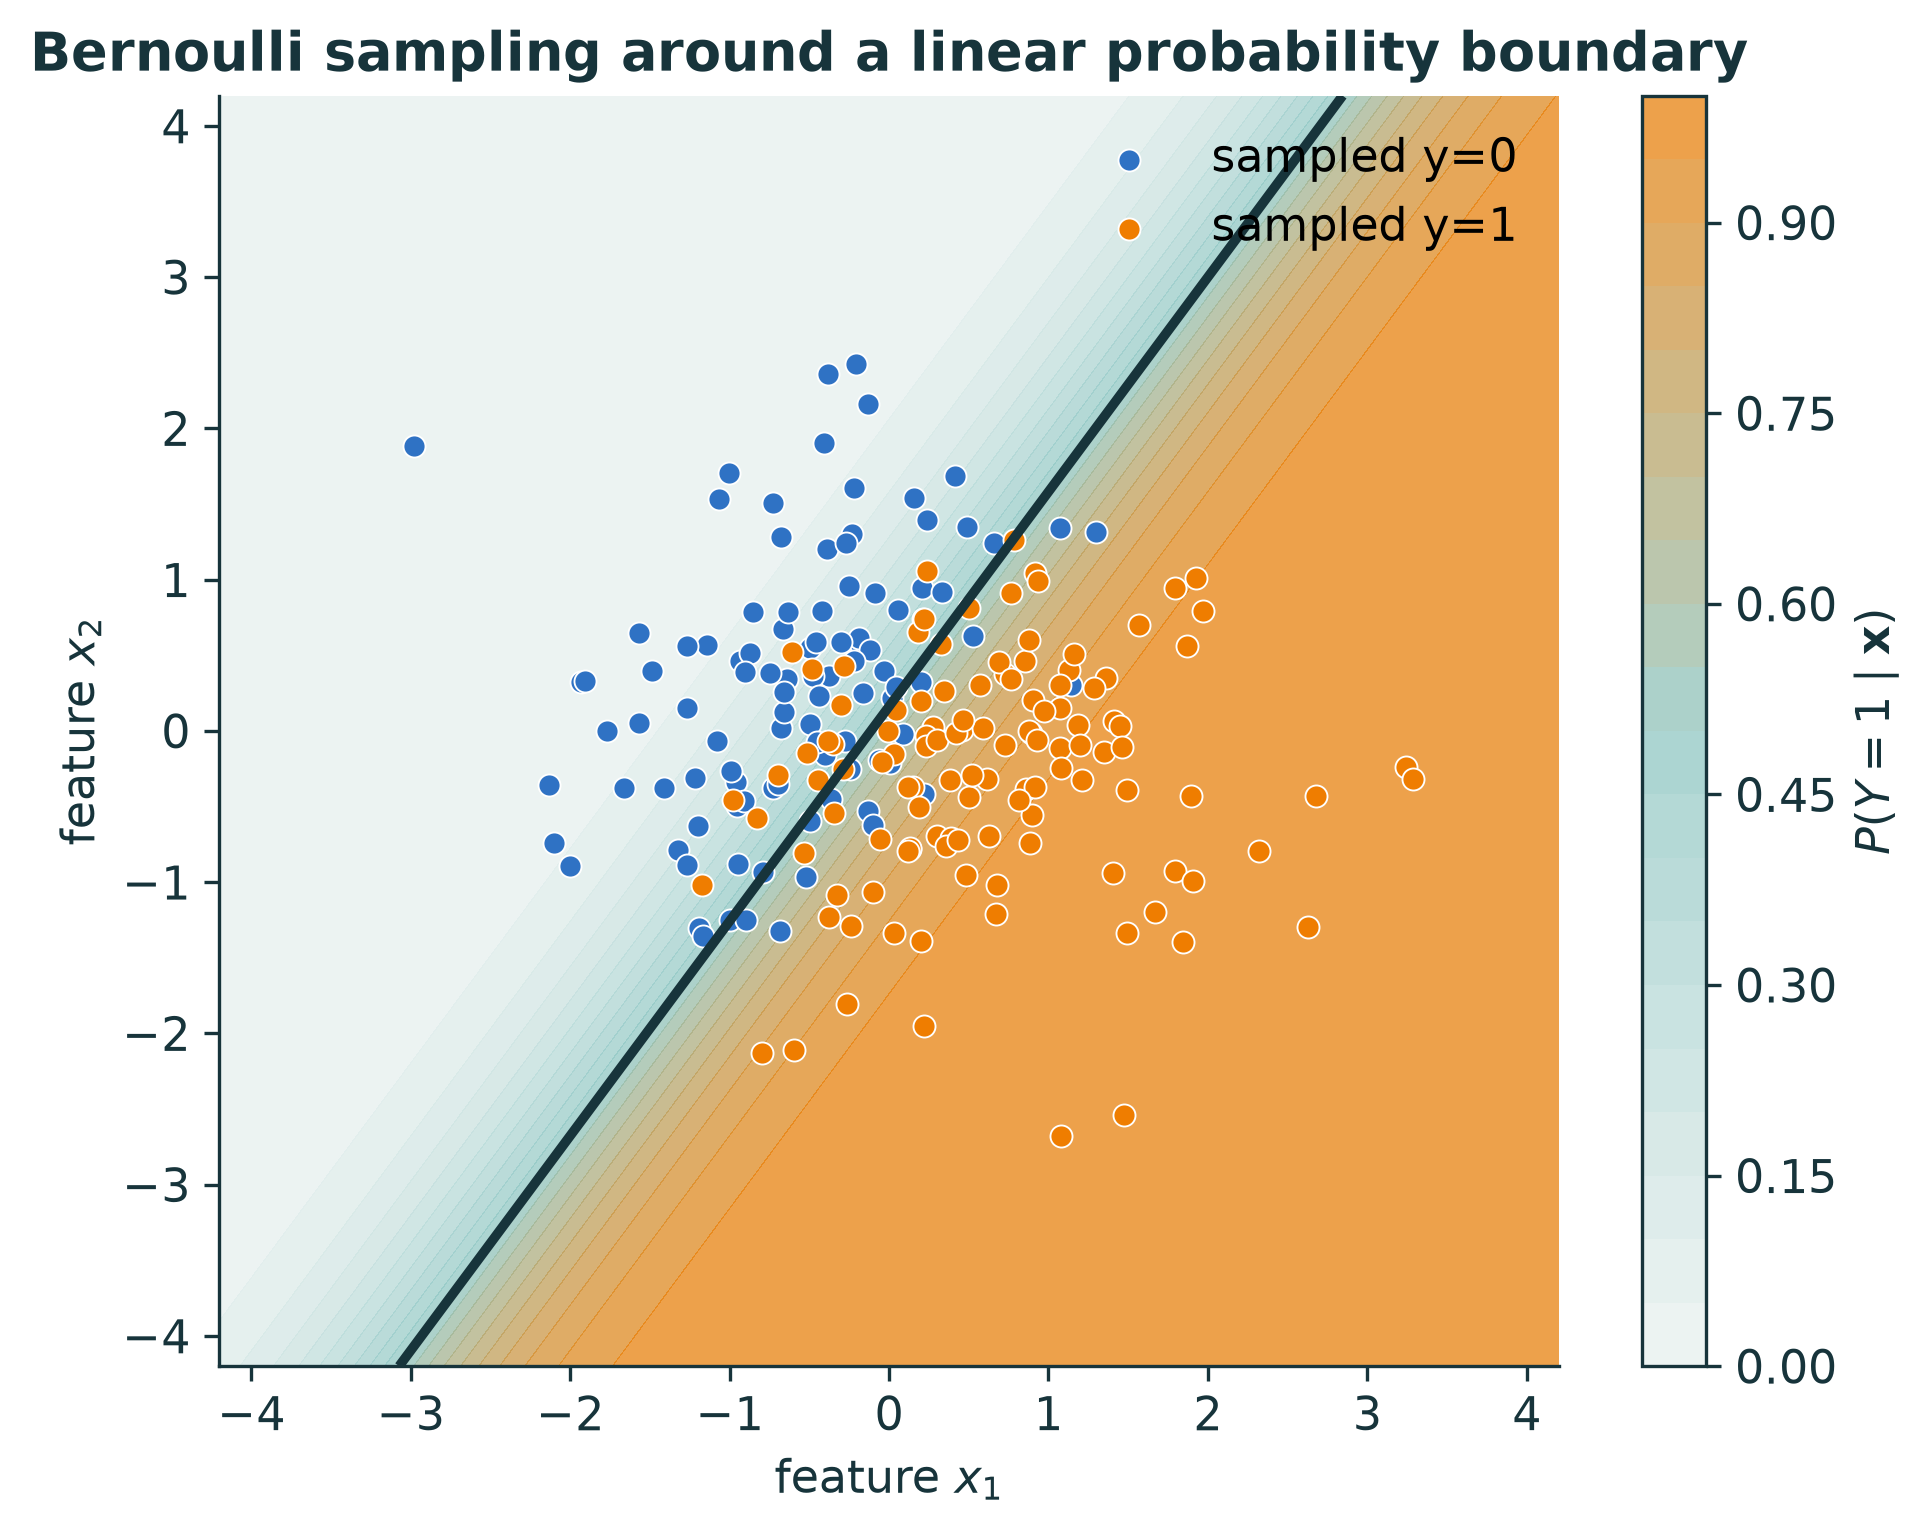

In [13]:
# Plot the generating probability and sampled classes
fig, ax = plt.subplots(figsize=(7.2, 5.5))
p_grid_true = probability_grid(theta_cls_true)
image = ax.contourf(npv(G1), npv(G2), npv(p_grid_true), levels=torch.linspace(0, 1, 21), cmap=probability_cmap, alpha=0.72)
ax.contour(npv(G1), npv(G2), npv(p_grid_true), levels=[0.5], colors=[INK], linewidths=2.3)
ax.scatter(npv(X_cls[y_cls == 0, 0]), npv(X_cls[y_cls == 0, 1]), s=28, color=BLUE, edgecolor="white", linewidth=0.45, label="sampled y=0")
ax.scatter(npv(X_cls[y_cls == 1, 0]), npv(X_cls[y_cls == 1, 1]), s=28, color=ORANGE, edgecolor="white", linewidth=0.45, label="sampled y=1")
ax.set(title="Bernoulli sampling around a linear probability boundary", xlabel=r"feature $x_1$", ylabel=r"feature $x_2$")
ax.legend(loc="upper right")
tidy(ax, grid=False)
fig.colorbar(image, ax=ax, label=r"$P(Y=1\mid\mathbf{x})$")
plt.show()


### Bernoulli `log_prob` is binary cross-entropy

Again: calculate one log-probability per example, then average or sum them. The next cell first verifies this with a five-example `for` loop, then uses the equivalent batch form inside the optimizer. Averaging changes the scale, not the optimizer.


In [14]:
# Compute five Bernoulli log-probabilities by hand
theta_at_start = torch.zeros(3)
manual_terms = []
for x_i, y_i in zip(X_cls[:5], y_cls[:5]):
    logit_i = theta_at_start[0] + x_i @ theta_at_start[1:]
    manual_terms.append(D.Bernoulli(logits=logit_i).log_prob(y_i))
manual_terms = torch.stack(manual_terms)
batched_terms = D.Bernoulli(logits=X_cls[:5] @ theta_at_start[1:] + theta_at_start[0]).log_prob(y_cls[:5])
print("five loop-computed log_prob terms:", manual_terms.tolist())
print("same as compact batch form?       ", torch.allclose(manual_terms, batched_terms))


five loop-computed log_prob terms: [-0.6931471805599453, -0.6931471805599453, -0.6931471805599453, -0.6931471805599453, -0.6931471805599453]
same as compact batch form?        True


In [ ]:
# Initialize logistic-regression parameters
theta_cls = torch.zeros(3, requires_grad=True)
optimizer = torch.optim.Adam([theta_cls], lr=0.08)
cls_history = []


In [ ]:
# Optimize the mean Bernoulli NLL
for step in range(500):
    optimizer.zero_grad()
    logits = theta_cls[0] + X_cls @ theta_cls[1:]
    per_example_log_prob = D.Bernoulli(logits=logits).log_prob(y_cls)
    loss = -per_example_log_prob.mean()
    loss.backward()
    optimizer.step()
    cls_history.append(loss.item())


In [ ]:
# Compare Bernoulli NLL with binary cross-entropy
with torch.no_grad():
    fitted_logits = theta_cls[0] + X_cls @ theta_cls[1:]
    nll = -D.Bernoulli(logits=fitted_logits).log_prob(y_cls).mean()
    bce = F.binary_cross_entropy_with_logits(fitted_logits, y_cls)


In [14]:
# Report the fitted classifier
print("true theta:  ", theta_cls_true.tolist())
print("MLE theta:   ", theta_cls.detach().round(decimals=3).tolist())
print(f"Bernoulli NLL: {nll.item():.12f}")
print(f"PyTorch BCE:   {bce.item():.12f}")
print("equal?         ", torch.allclose(nll, bce))


true theta:   [0.25, 2.2, -1.55]
MLE theta:    [0.295, 3.234, -2.068]
Bernoulli NLL: 0.319280198231
PyTorch BCE:   0.319280198231
equal?          True


In [ ]:
# Evaluate the fitted probability surface
theta_cls_fit = theta_cls.detach()
p_grid_fit = probability_grid(theta_cls_fit)


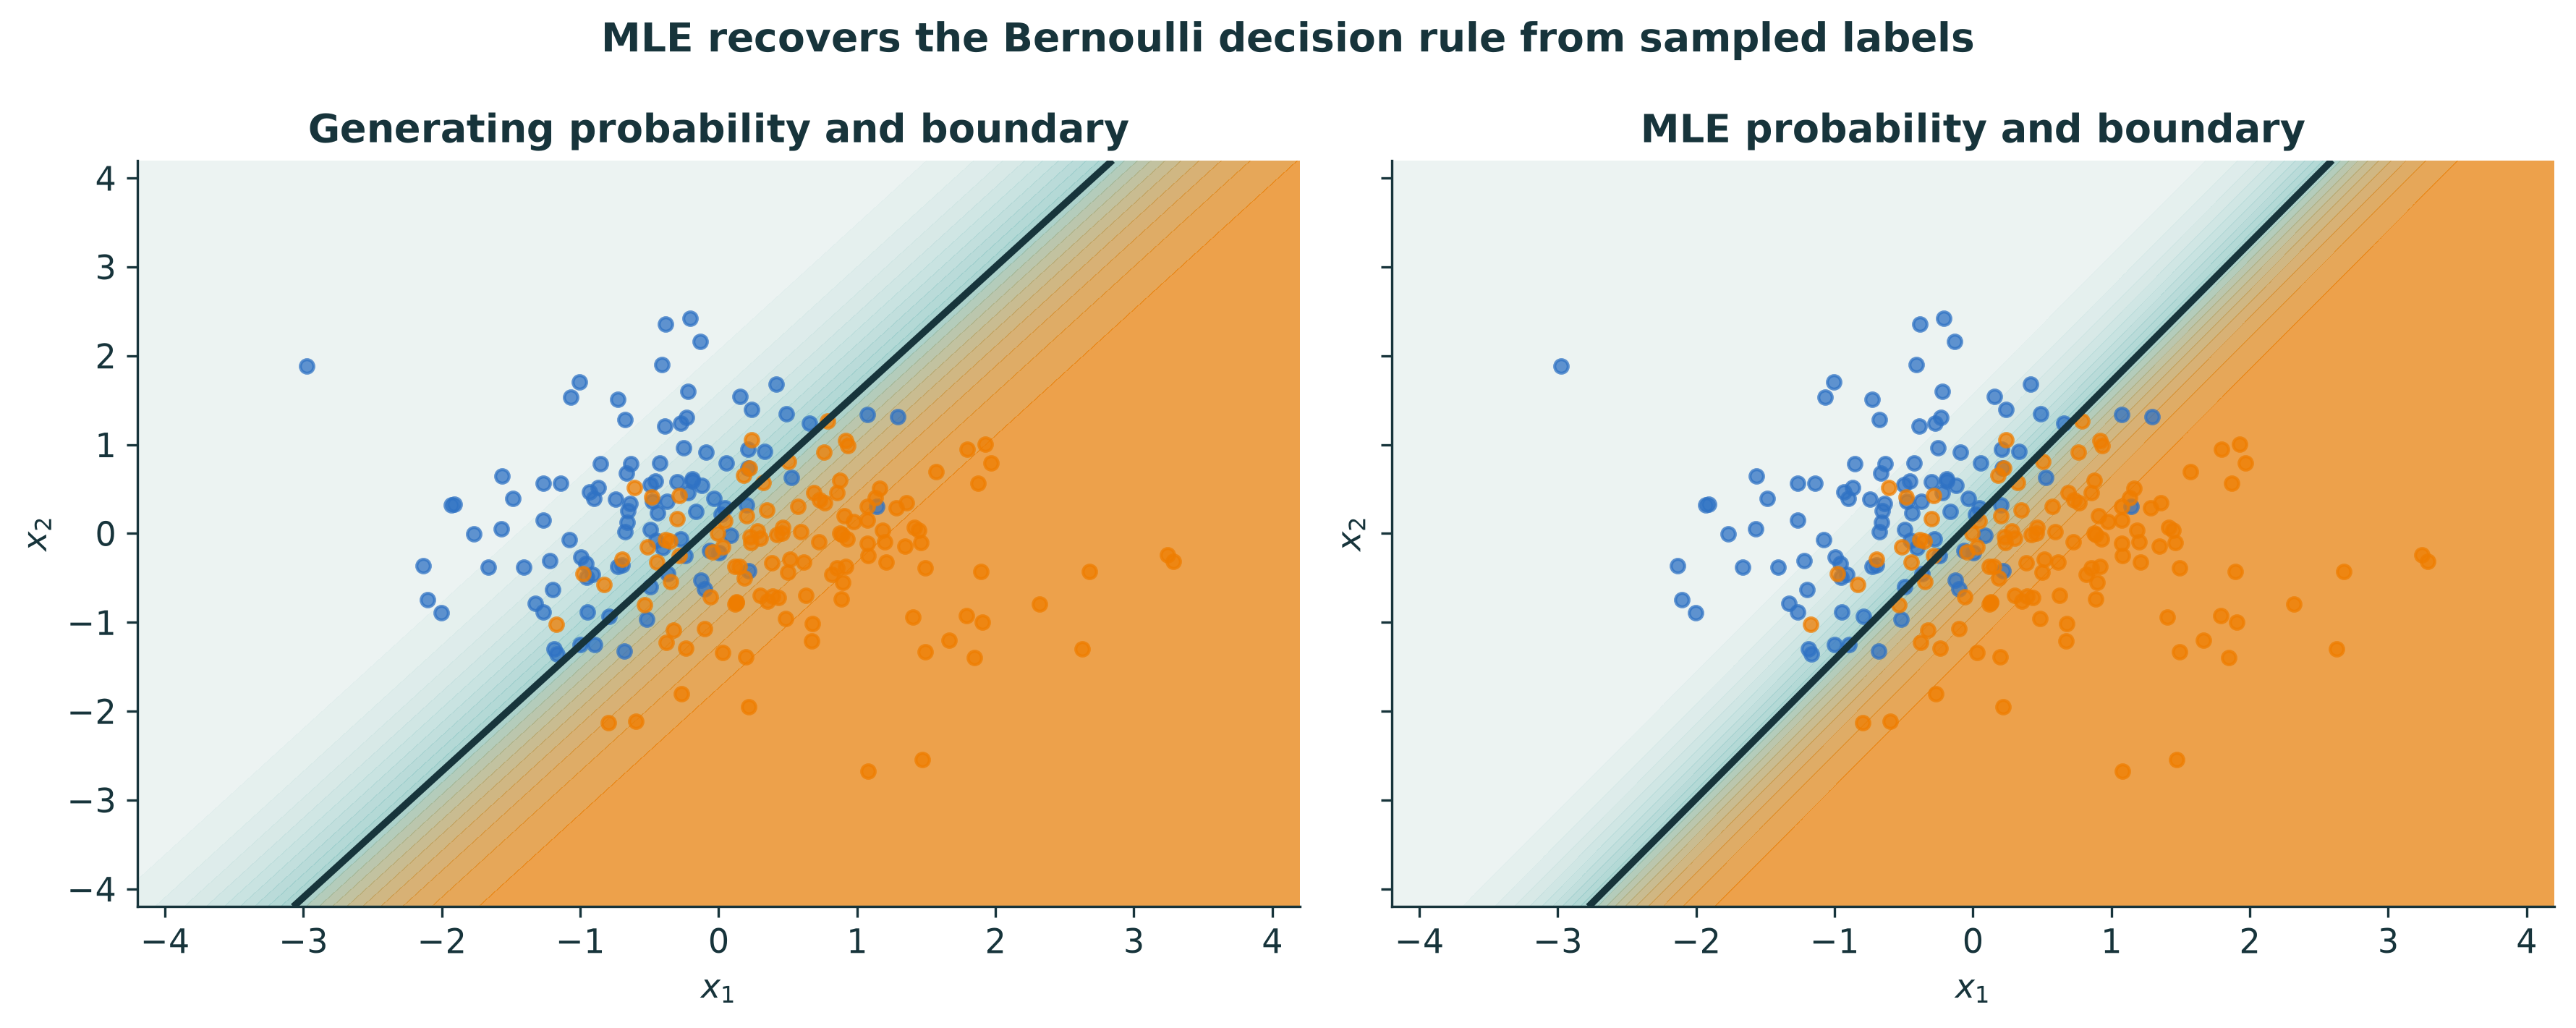

In [15]:
# Compare generating and fitted decision boundaries
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True, sharey=True)
for ax, p_grid, title in [
    (axes[0], p_grid_true, "Generating probability and boundary"),
    (axes[1], p_grid_fit, "MLE probability and boundary"),
]:
    ax.contourf(npv(G1), npv(G2), npv(p_grid), levels=torch.linspace(0, 1, 21), cmap=probability_cmap, alpha=0.72)
    ax.contour(npv(G1), npv(G2), npv(p_grid), levels=[0.5], colors=[INK], linewidths=2.3)
    ax.scatter(npv(X_cls[y_cls == 0, 0]), npv(X_cls[y_cls == 0, 1]), s=20, color=BLUE, alpha=0.75)
    ax.scatter(npv(X_cls[y_cls == 1, 0]), npv(X_cls[y_cls == 1, 1]), s=20, color=ORANGE, alpha=0.75)
    ax.set(title=title, xlabel=r"$x_1$", ylabel=r"$x_2$")
    tidy(ax, grid=False)

# Display the classifier comparison
fig.suptitle("MLE recovers the Bernoulli decision rule from sampled labels", fontweight="bold", color=INK)
fig.tight_layout()
plt.show()


## 7 · MAP adds a prior to the same likelihood

For parameters $\boldsymbol\theta=(b,w)$,

$$\log p(\boldsymbol\theta\mid\mathcal D)
=\log p(\mathcal D\mid\boldsymbol\theta)
+\log p(\boldsymbol\theta)-\log p(\mathcal D).$$

The evidence $\log p(\mathcal D)$ is constant with respect to $\boldsymbol\theta$, so

$$\hat{\boldsymbol\theta}_{\mathrm{MAP}}
=\arg\min_{\boldsymbol\theta}
\underbrace{-\log p(\mathcal D\mid\boldsymbol\theta)}_{\text{data NLL}}
+\underbrace{-\log p(\boldsymbol\theta)}_{\text{prior penalty}}.$$

If the prior treats $b$ and $w$ as independent, its log-probability is also a simple sum: $\log p(b,w)=\log p(b)+\log p(w)$.


In [ ]:
# Select a deliberately small regression dataset
# Use eight observations spread across the input domain: genuinely small data,
# without turning estimation into one-sided extrapolation.
small_idx = torch.linspace(0, x_reg.numel() - 1, 8).round().long()
x_small = x_reg[small_idx]
y_small = y_reg[small_idx]
sigma_small = torch.tensor(0.62)
design_small = torch.column_stack((torch.ones_like(x_small), x_small))
theta_mle_small = torch.linalg.lstsq(design_small, y_small).solution


In [ ]:
# Define a zero-centred Gaussian parameter prior
tau = torch.tensor(1.0)
one_parameter_prior = D.Normal(loc=torch.tensor(0.0), scale=tau)


In [ ]:
# Evaluate likelihood and prior over parameter space
b_map = torch.linspace(-0.5, 3.3, 170)
w_map = torch.linspace(-0.2, 4.8, 170)
BM, WM = torch.meshgrid(b_map, w_map, indexing="xy")
mean_map_grid = BM[..., None] + WM[..., None] * x_small
log_like_grid = D.Normal(mean_map_grid, sigma_small).log_prob(y_small).sum(dim=-1)
log_prior_grid = torch.zeros_like(BM)
for parameter_grid in [BM, WM]:
    log_prior_grid = log_prior_grid + one_parameter_prior.log_prob(parameter_grid)
log_posterior_grid = log_like_grid + log_prior_grid


In [ ]:
# Define a helper for locating a surface maximum
def grid_argmax(surface):
    idx = surface.argmax()
    row = idx // surface.shape[1]
    col = idx % surface.shape[1]
    return torch.tensor([BM[row, col], WM[row, col]])


In [ ]:
# Find the Gaussian MAP estimate
theta_map_gaussian = grid_argmax(log_posterior_grid)


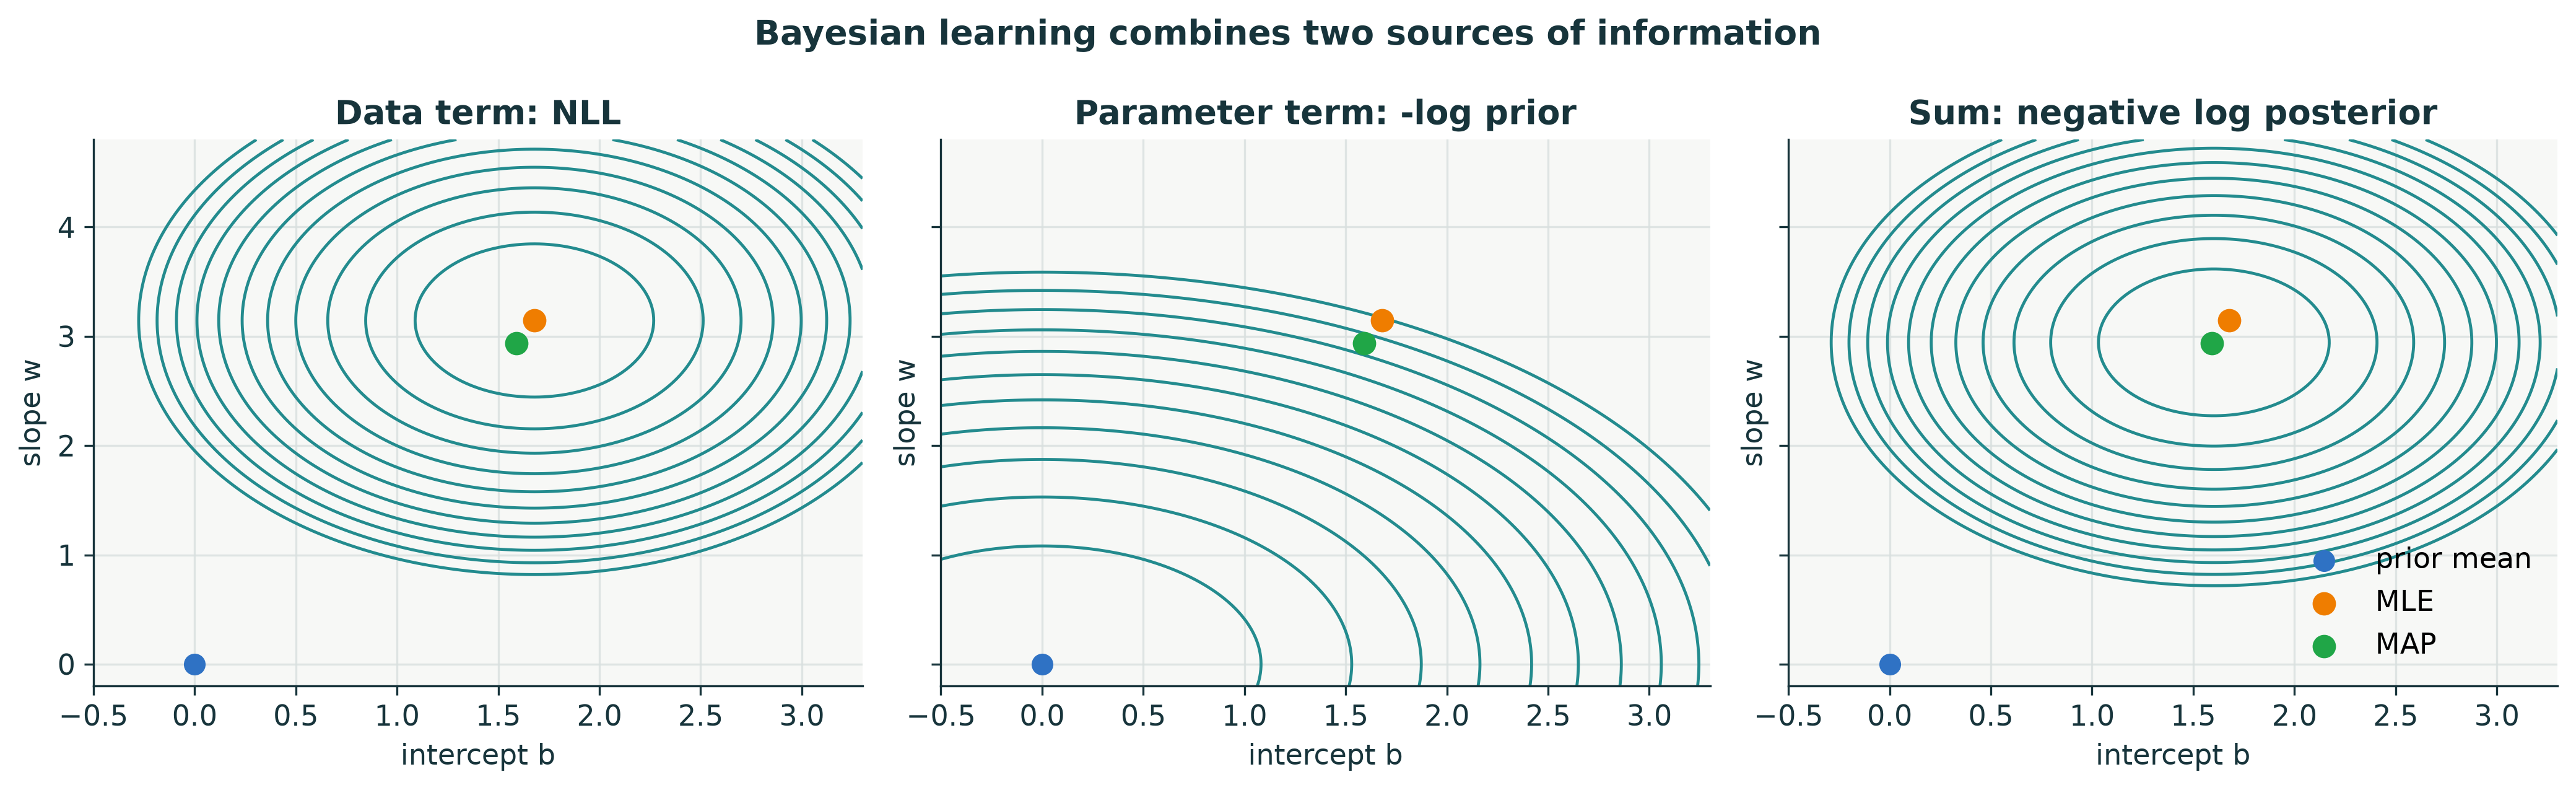

In [16]:
# Prepare the data, prior, and posterior panels
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3), sharex=True, sharey=True)
panels = [
    (-log_like_grid, "Data term: NLL"),
    (-log_prior_grid, "Parameter term: -log prior"),
    (-log_posterior_grid, "Sum: negative log posterior"),
]

# Draw all three parameter-space contour plots
for ax, (surface, title) in zip(axes, panels):
    shifted = surface - surface.min()
    upper = torch.quantile(shifted.flatten(), 0.65)
    levels = torch.linspace(torch.tensor(0.0), upper, 12)
    ax.contour(npv(BM), npv(WM), npv(shifted), levels=npv(levels), colors=TEAL, linewidths=1.15)
    ax.scatter(0, 0, color=BLUE, s=55, label="prior mean", zorder=4)
    ax.scatter(theta_mle_small[0], theta_mle_small[1], color=ORANGE, s=65, label="MLE", zorder=4)
    ax.scatter(theta_map_gaussian[0], theta_map_gaussian[1], color=GREEN, s=65, label="MAP", zorder=4)
    ax.set(title=title, xlabel="intercept b", ylabel="slope w")
    tidy(ax)

# Display the Bayesian decomposition
axes[-1].legend(loc="lower right")
fig.suptitle("Bayesian learning combines two sources of information", fontweight="bold", color=INK)
fig.tight_layout()
plt.show()


In [16]:
# Compare the MLE and MAP parameters
print("small-data MLE [b, w]:", theta_mle_small.round(decimals=3).tolist())
print("Gaussian MAP [b, w]:  ", theta_map_gaussian.round(decimals=3).tolist())


small-data MLE [b, w]: [1.679, 3.145]
Gaussian MAP [b, w]:   [1.591, 2.936]


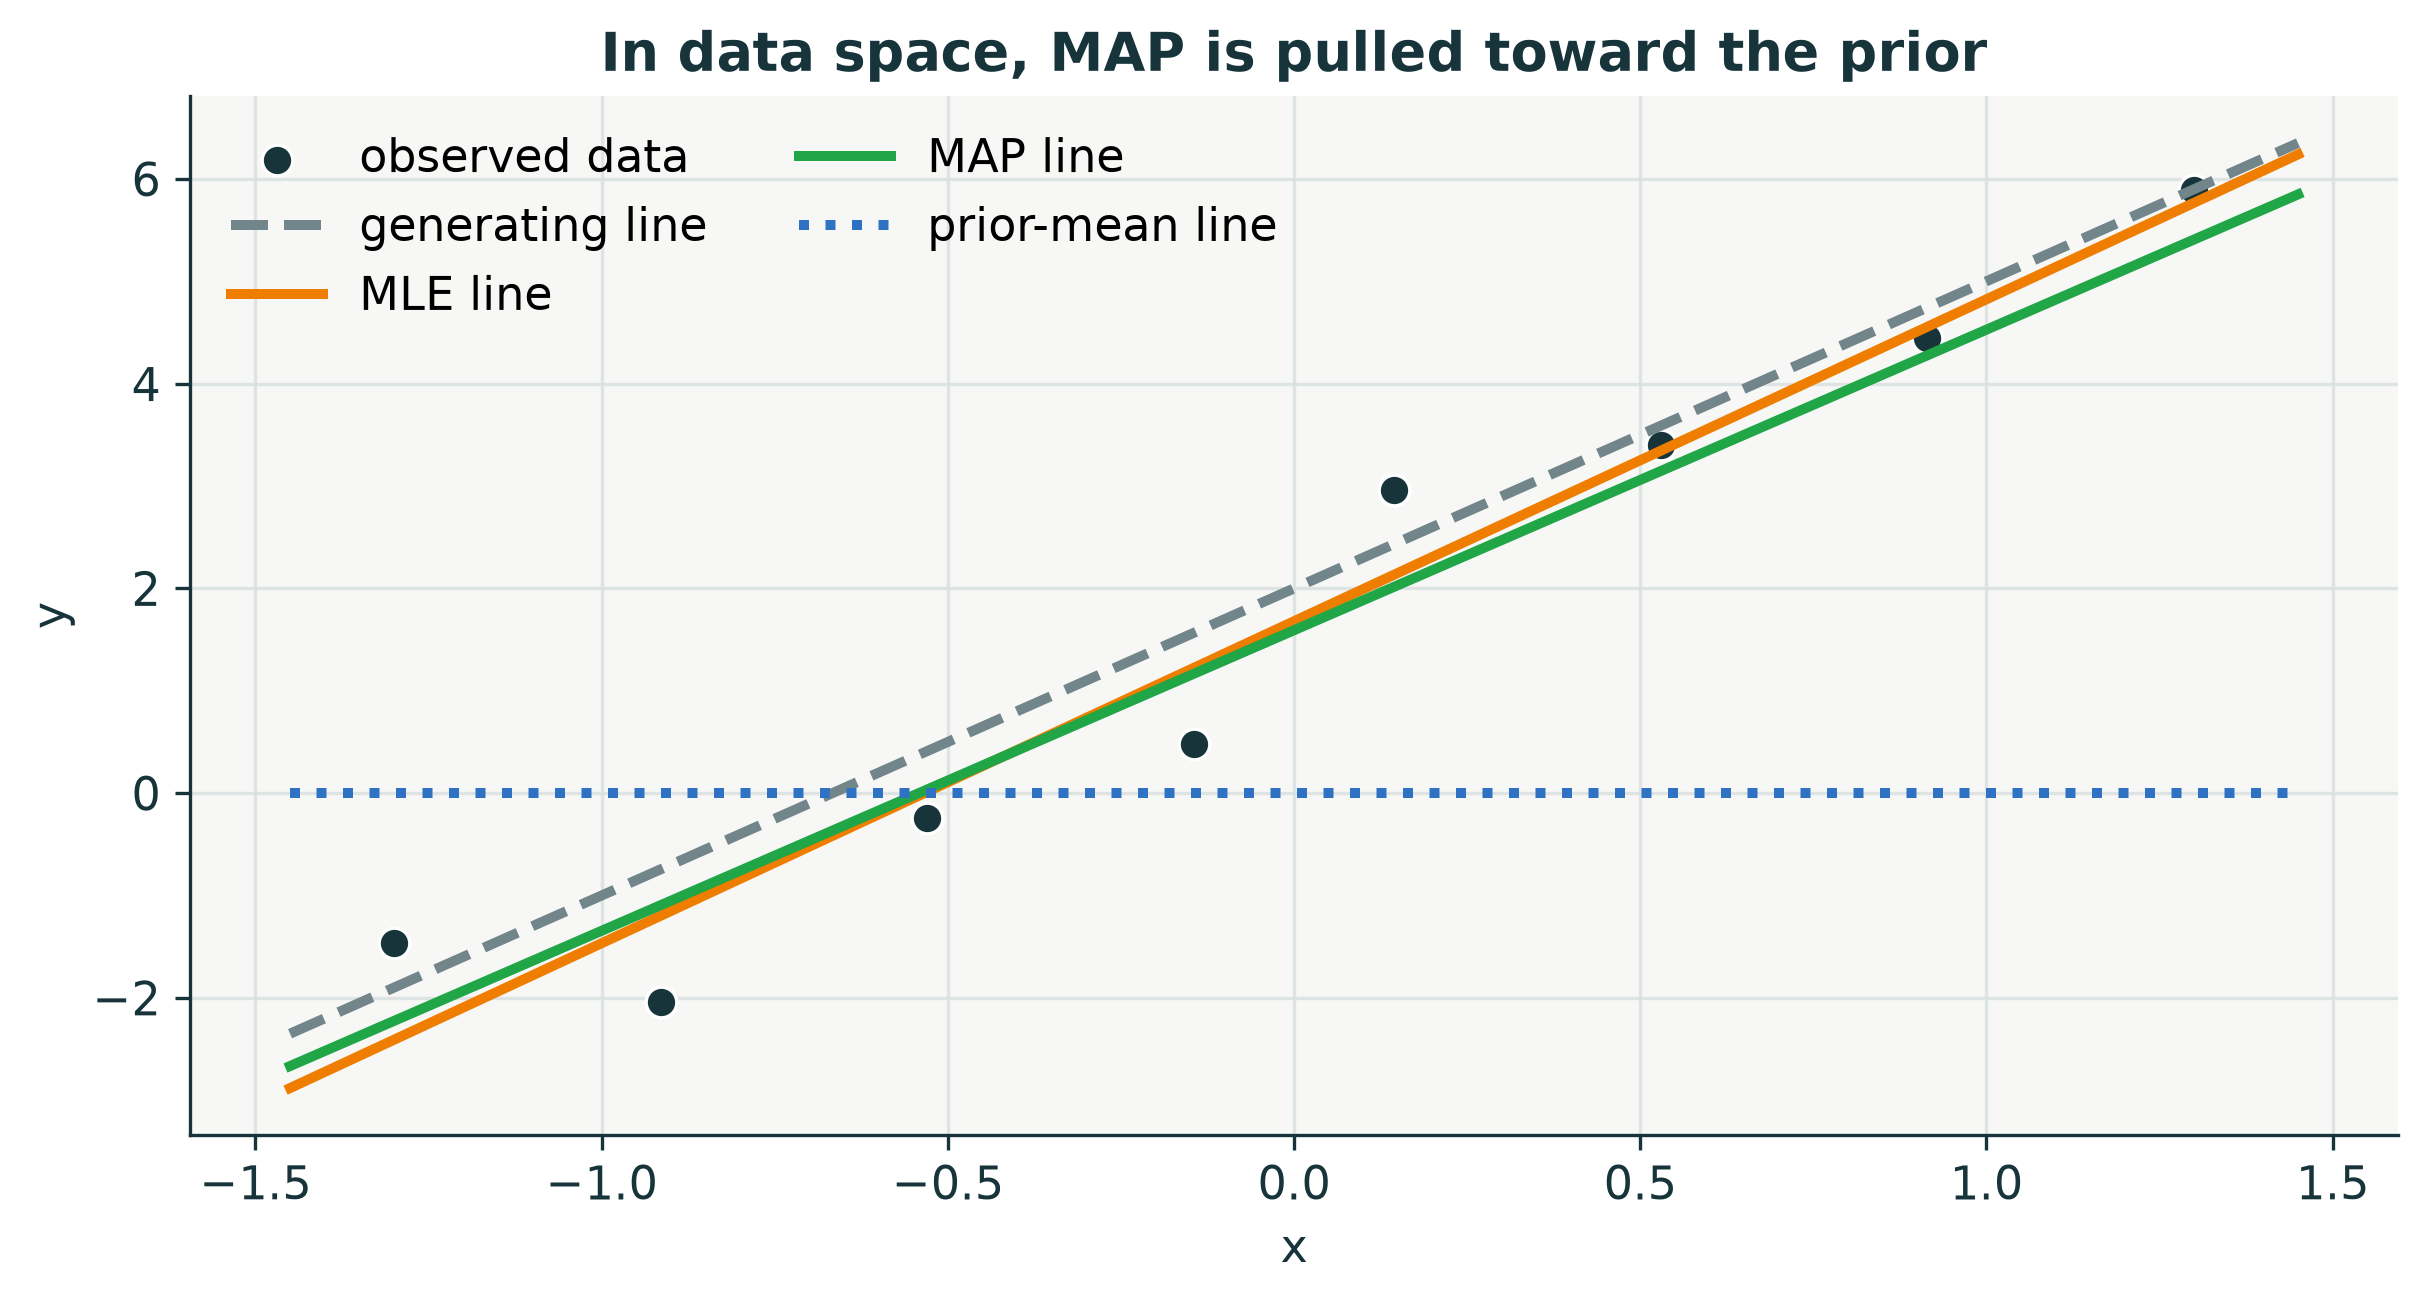

In [17]:
# Compare MLE, MAP, and prior-mean lines in data space
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.scatter(npv(x_small), npv(y_small), s=54, color=INK, edgecolor="white", linewidth=0.8, label="observed data")
ax.plot(npv(x_dense), npv(theta_true[0] + theta_true[1] * x_dense), color=MUTED, linestyle="--", label="generating line")
ax.plot(npv(x_dense), npv(theta_mle_small[0] + theta_mle_small[1] * x_dense), color=ORANGE, label="MLE line")
ax.plot(npv(x_dense), npv(theta_map_gaussian[0] + theta_map_gaussian[1] * x_dense), color=GREEN, label="MAP line")
ax.plot(npv(x_dense), torch.zeros_like(x_dense), color=BLUE, linestyle=":", label="prior-mean line")
ax.set(title="In data space, MAP is pulled toward the prior", xlabel="x", ylabel="y")
ax.legend(ncols=2)
tidy(ax)
plt.show()


## 8 · The prior distribution determines the regularizer

We compare three zero-centred priors for one parameter:

- Normal: $-\log p(\theta)$ grows quadratically ($L_2$);
- Laplace: it grows linearly and has a corner at zero ($L_1$);
- Student-$t$: it grows slowly in the tails, so large coefficients are penalized less aggressively.


In [ ]:
# Define Normal, Laplace, and Student-t priors
theta_line = torch.linspace(-5, 5, 1201)
priors_1d = {
    "Normal": (D.Normal(0.0, 1.0), BLUE),
    "Laplace": (D.Laplace(0.0, 1.0 / math.sqrt(2)), ORANGE),
    "Student-t (df=3)": (D.StudentT(3.0, 0.0, 1.0 / math.sqrt(3)), TEAL),
}


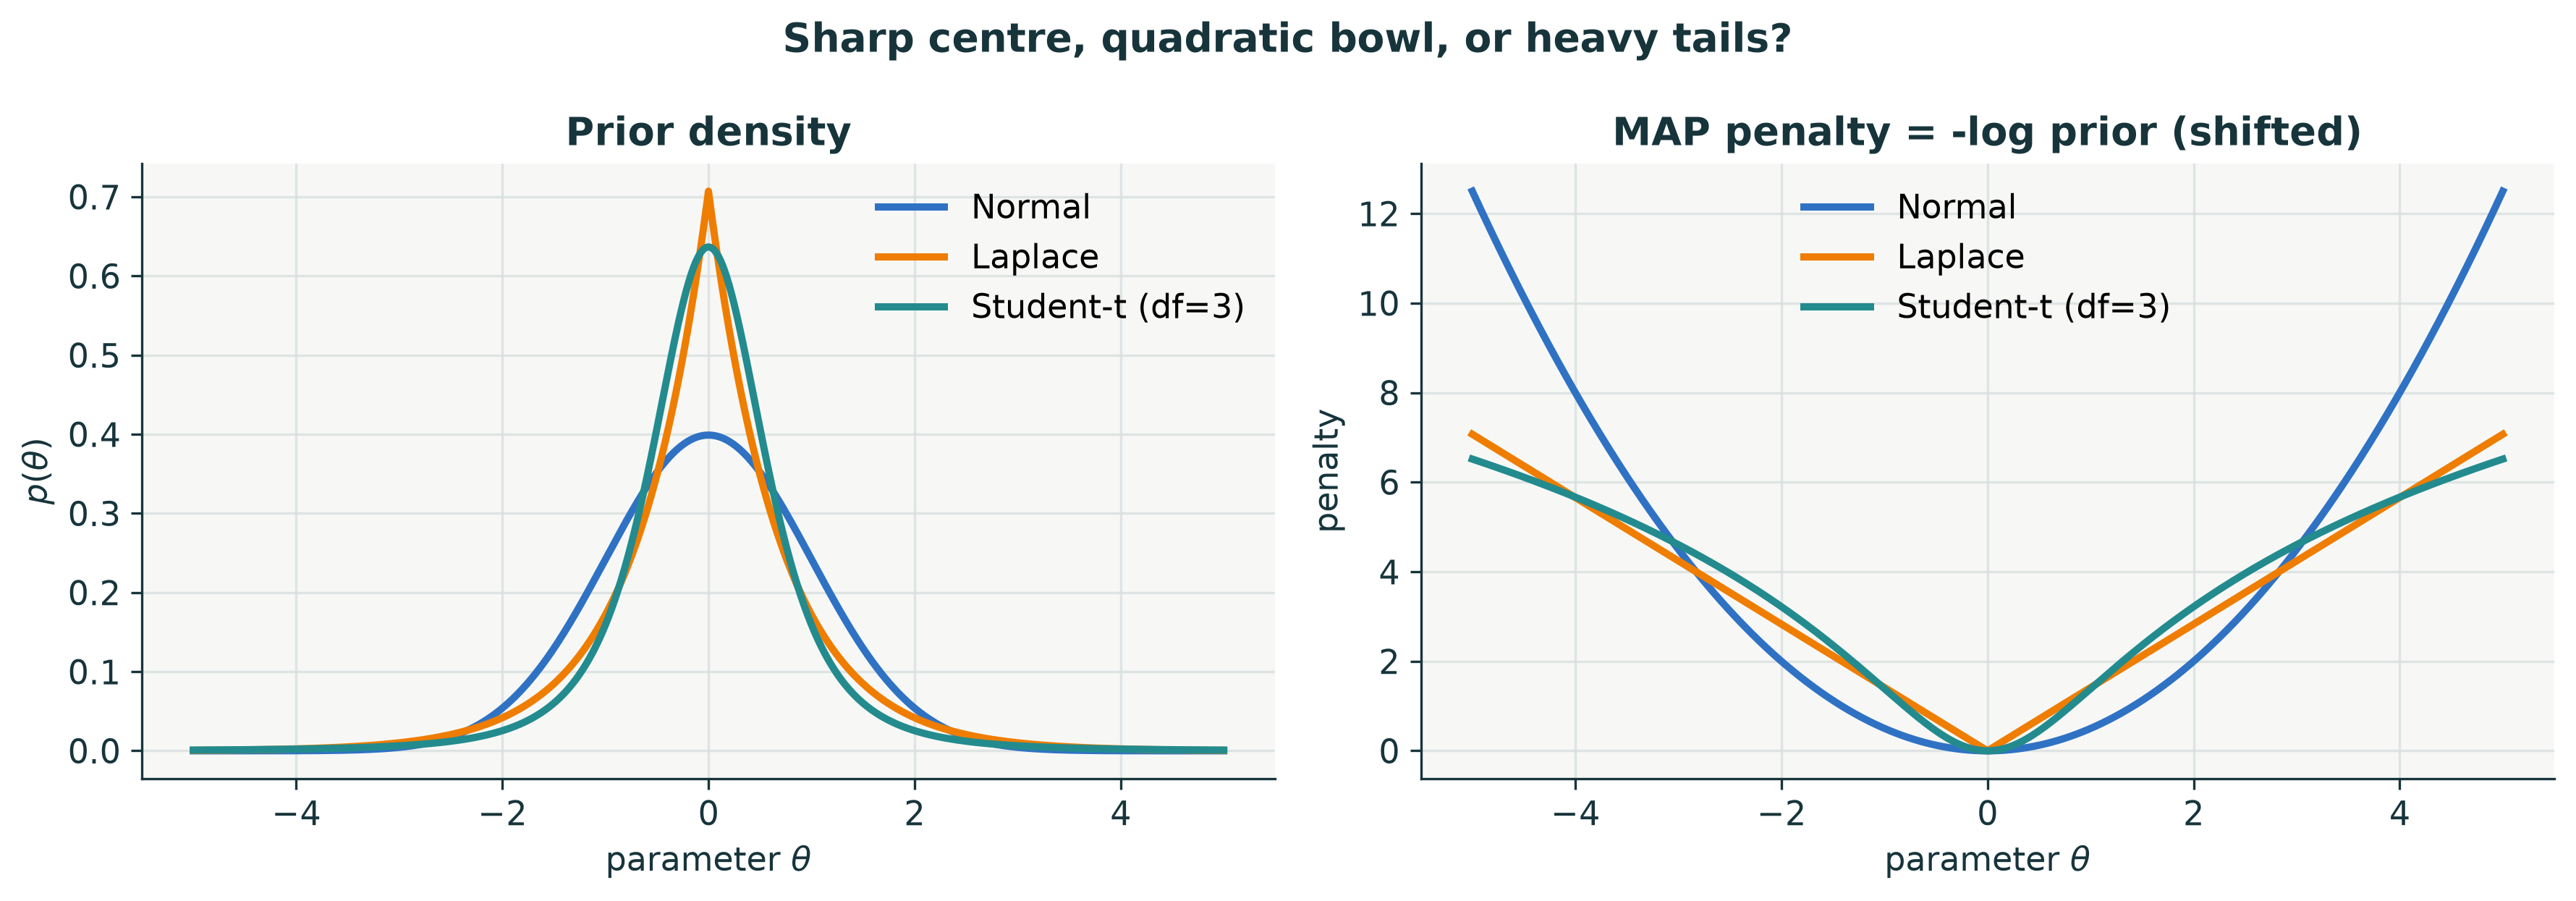

In [18]:
# Compare prior densities with their MAP penalties
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for name, (prior, color) in priors_1d.items():
    log_density = prior.log_prob(theta_line)
    penalty = -log_density
    penalty = penalty - penalty.min()
    axes[0].plot(npv(theta_line), npv(log_density.exp()), color=color, label=name)
    axes[1].plot(npv(theta_line), npv(penalty), color=color, label=name)

# Label and display the prior comparison
axes[0].set(title="Prior density", xlabel=r"parameter $\theta$", ylabel=r"$p(\theta)$")
axes[1].set(title="MAP penalty = -log prior (shifted)", xlabel=r"parameter $\theta$", ylabel="penalty")
for ax in axes:
    ax.legend()
    tidy(ax)
fig.suptitle("Sharp centre, quadratic bowl, or heavy tails?", fontweight="bold", color=INK)
fig.tight_layout()
plt.show()


### Why can a Laplace prior produce an exact zero?

Consider a weak one-parameter likelihood whose MLE is $0.35$. We combine the **same likelihood** with three priors and inspect the MAP point.


In [ ]:
# Define a weak one-dimensional likelihood
weak_mle = torch.tensor(0.35)
weak_likelihood_sd = torch.tensor(0.60)
theta_zoom = torch.linspace(-1.5, 1.5, 3001)
weak_log_likelihood = D.Normal(theta_zoom, weak_likelihood_sd).log_prob(weak_mle)


In [ ]:
# Choose three contrasting parameter priors
comparison_priors = {
    "Normal prior": (D.Normal(0.0, 1.0), BLUE),
    "Laplace prior": (D.Laplace(0.0, 0.80), ORANGE),
    "Student-t prior": (D.StudentT(3.0, 0.0, 0.70), TEAL),
}


likelihood-only MLE = 0.350
Normal prior     MAP =  0.257
Laplace prior    MAP = -0.000
Student-t prior  MAP =  0.179


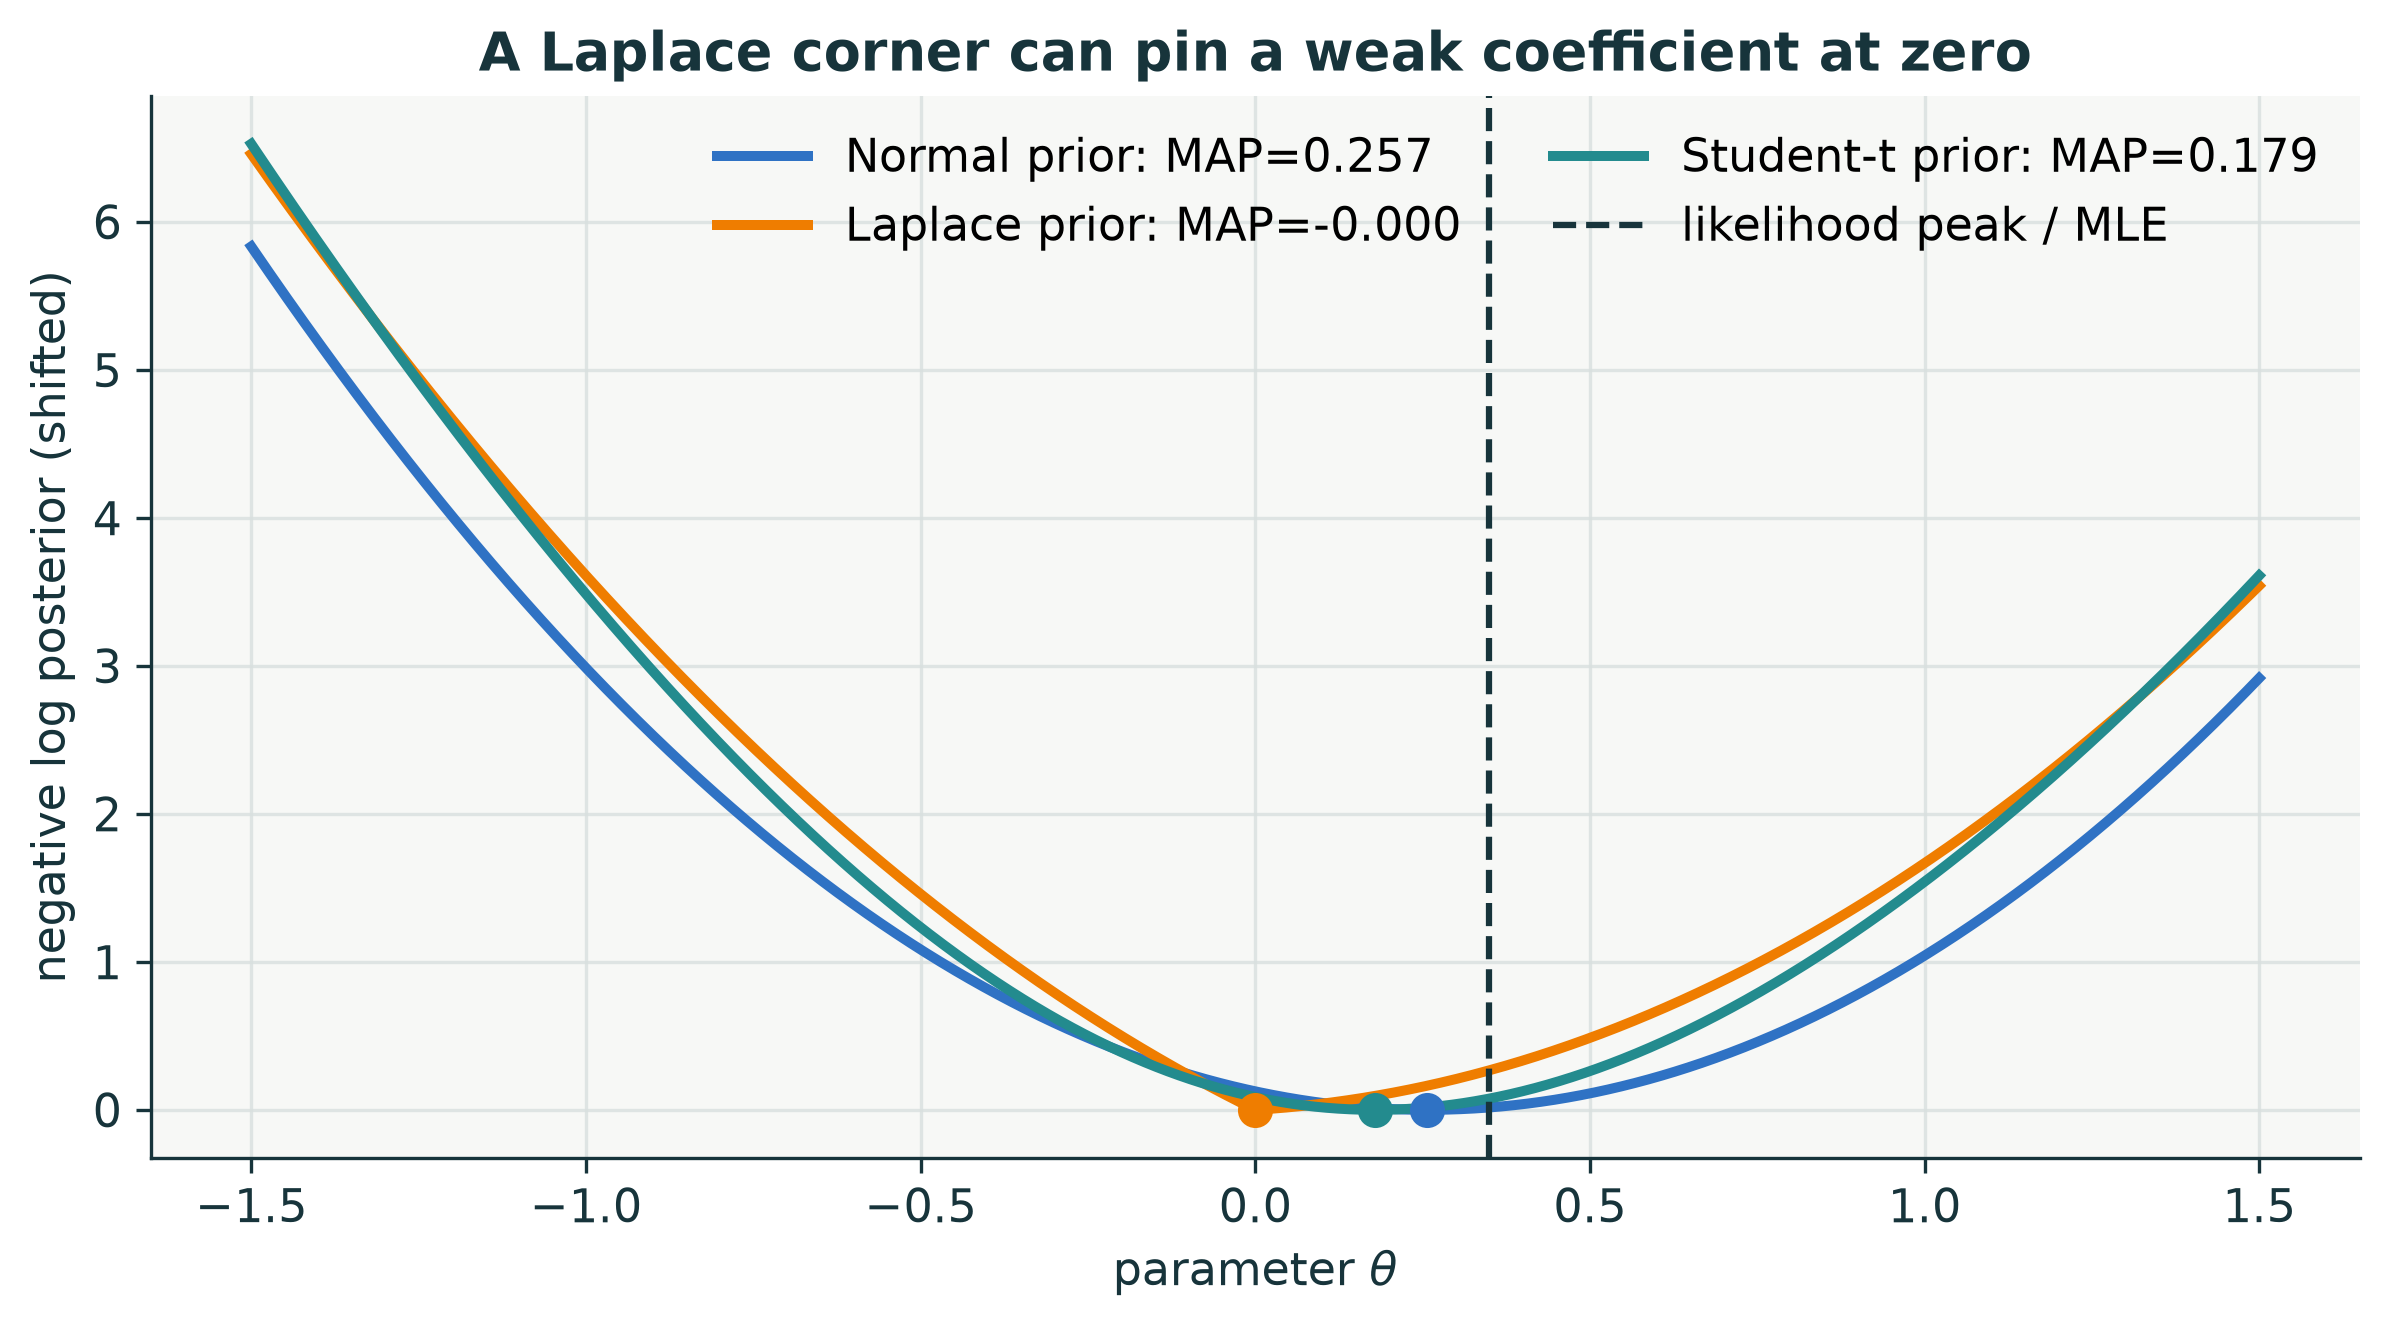

In [19]:
# Find and plot the MAP under each prior
fig, ax = plt.subplots(figsize=(9.5, 4.6))
print(f"likelihood-only MLE = {weak_mle.item():.3f}")
for name, (prior, color) in comparison_priors.items():
    objective = -(weak_log_likelihood + prior.log_prob(theta_zoom))
    objective = objective - objective.min()
    map_value = theta_zoom[objective.argmin()]
    ax.plot(npv(theta_zoom), npv(objective), color=color, label=f"{name}: MAP={map_value.item():.3f}")
    ax.scatter(map_value, 0, color=color, s=55, zorder=4)
    print(f"{name:16s} MAP = {map_value.item(): .3f}")

# Mark the likelihood-only estimate and display the result
ax.axvline(weak_mle, color=INK, linestyle="--", linewidth=1.5, label="likelihood peak / MLE")
ax.set(title="A Laplace corner can pin a weak coefficient at zero", xlabel=r"parameter $\theta$", ylabel="negative log posterior (shifted)")
ax.legend(ncols=2)
tidy(ax)
plt.show()


## 9 · Final mental model

| Task | PyTorch distribution | Objective |
|---|---|---|
| coin bias | `D.Bernoulli(probs=theta)` | `-log_prob(data).sum()` |
| linear regression | `D.Normal(mean, sigma)` | Gaussian NLL = scaled MSE + constant |
| binary classification | `D.Bernoulli(logits=logits)` | Bernoulli NLL = binary cross-entropy |
| MAP | likelihood **and** a prior distribution | data NLL + negative log prior |

**Three checks to ask whenever you see a loss**

1. What observation distribution does this loss assume?
2. Which examples are being treated as independent, and which parameters are shared?
3. Is there a prior/regularizer, and what parameter values does it prefer?

### Optional student experiments

- Replace the regression Normal with `D.StudentT(df=3, ...)`, add one outlier, and compare the fitted line.
- Change the number of coin flips while keeping the same head fraction. Watch the likelihood sharpen.
- Increase or decrease `tau` in the Gaussian prior. Track how far MAP moves from MLE.
- Replace the Bernoulli-generated labels with deterministic threshold labels. What happens to the logistic-regression parameter magnitudes?
